# film revenue prediction - project notebook

## sections
1. project overview
2. data acquisition
3. pre-cleaning eda
4. data merging
5. data cleaning
6. post-cleaning eda
7. train / val / test split
8. data leakage analysis
9. feature engineering
10. multimodal fusion
11. baseline model
12. evaluation metrics
13. model selection + hyperparameter tuning
14. ablation study
15. fine-tuning experiment
16. interpretability with shap
17. report-ready outputs
18. pitfalls checklist

In [1]:
# setup
import os
import gc
import sys
import ast
import json
import requests
from io import BytesIO
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import psutil

# NO torch imports here — embeddings are already cached on disk
# importing torch loads the allocator and costs ~10GB RAM

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    precision_score, recall_score, f1_score, roc_auc_score,
)

# openmp fix for lightgbm on apple silicon
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

ROOT = Path.cwd()
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

SEED = 42
np.random.seed(SEED)

print(f"memory at startup: {psutil.Process(os.getpid()).memory_info().rss / 1024**2:.0f} MB")

memory at startup: 238 MB


# Here we'll define the evaluton helpers so every downstream section can call them without ordering issues

Here we set the random seed for reproducibility. Evaluate_regression and evaluate_classification are called in sectins 11,13,14 and 17, define them here for clearer code running.

In [2]:
def evaluate_regression(y_true, y_pred, label="model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{label} — rmse: {rmse:.4f} | mae: {mae:.4f} | r2: {r2:.4f}")
    return {"rmse": rmse, "mae": mae, "r2": r2}

def evaluate_classification(y_true_binary, y_pred_proba, label="model"):
    """
    y_pred_proba should be continuous predicted probabilities (or scores),
    not hard binary labels — roc_auc_score requires a score, not a 0/1 array.
    """
    y_pred_binary = (y_pred_proba >= 0.5).astype(int)
    p   = precision_score(y_true_binary, y_pred_binary, zero_division=0)
    r   = recall_score(y_true_binary, y_pred_binary, zero_division=0)
    f1  = f1_score(y_true_binary, y_pred_binary, zero_division=0)
    auc = roc_auc_score(y_true_binary, y_pred_proba)
    print(f"{label} — precision: {p:.3f} | recall: {r:.3f} | f1: {f1:.3f} | auc: {auc:.3f}")
    return {"precision": p, "recall": r, "f1": f1, "auc": auc}

## 1) project overview

### 1.1 central research question
- what matters more for pre-release prediction: feature representation or model choice?

### 1.2 prediction target
- primary target: `y = log1p(revenue)` (not raw revenue). Revenue ranges from thousands to billions — a model trying to predict raw dollars would be dominated by blockbusters. Taking the logarithm compresses this range so every film contributes meaningfully to training, not just the mega-hits.
- derived label: `profitable = 1[revenue > 1.5 * budget]` turns it into a classification problem too: was this film worth making? The 1.5× threshold accounts for the fact that studios typically need revenue significantly above budget to actually profit after marketing and distribution costs.

### 1.3 core thesis
- combining structured metadata + synopsis embeddings + poster embeddings should outperform any single modality.

## 2) data acquisition

### 2.1 tmdb (kaggle)
- `TMDB_movie_dataset_v11.csv`:  has budget, revenue, genres, overview, poster, language, production country. ~1.4 million entries including TV, shorts, and unreleased films.

### 2.2 imdb non-commercial files: 
Has structured director and cast information by person ID. More reliable than TMDB's text fields for talent lookup.
- `title.crew.tsv.csv` (gzipped)
- `title.principals.tsv.csv` (gzipped)
- `name.basics.tsv.csv` (gzipped)

Why combine both? Neither source alone is complete. TMDB has financial data; IMDb has structured talent data. Joining them gives you both.

### 2.3 poster images
- build url: `https://image.tmdb.org/t/p/w342/{poster_path}`
- cache locally before embedding extraction

In [3]:
# load raw datasets
TMDB_PATH       = ROOT / "data/raw/TMDB_movie_dataset_v11.csv"
CREW_PATH       = ROOT / "data/raw/title.crew.tsv.csv"
PRINCIPALS_PATH = ROOT / "data/raw/title.principals.tsv.csv"
NAMES_PATH      = ROOT / "data/raw/name.basics.tsv.csv"


tmdb       = pd.read_csv(TMDB_PATH)
crew       = pd.read_csv(CREW_PATH,       sep='\t', low_memory=False)
principals = pd.read_csv(PRINCIPALS_PATH, sep='\t', low_memory=False)
names      = pd.read_csv(NAMES_PATH,      sep='\t', low_memory=False)

print(f"tmdb:       {tmdb.shape}")
print(f"crew:       {crew.shape}")
print(f"principals: {principals.shape}")
print(f"names:      {names.shape}")
tmdb.head()

tmdb:       (1419084, 24)
crew:       (12485800, 3)
principals: (99326376, 6)
names:      (15306875, 6)


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


## 3) pre-cleaning eda

- Missing values check: tells you which columns are mostly empty. If budget is 80% missing, you can't just impute it — you have to decide whether to drop those rows or the column entirely.
- Duplicates check: TMDB sometimes lists the same film multiple times (different regional entries). Training on duplicates biases the model — it effectively sees those films multiple times and learns to weight them more.
- Financial outlier plots on log scale: revenue and budget span many orders of magnitude (from $1 to $300M+). A regular histogram would show one giant bar near zero and nothing else. Log scale reveals the actual shape: there's a suspicious cluster of entries with $1 budgets, which are clearly data entry errors, not real films.
- Runtime, language, country distributions: these tell you how skewed the data is and what categories are rare enough that you'll need to group them later.

### pre-cleaning frame

create a raw tmdb copy so checks are isolated and reproducible.


In [4]:
# pre-cleaning frame from raw tmdb table
pre_df = tmdb.copy()
print(f"raw tmdb shape: {pre_df.shape}")


raw tmdb shape: (1419084, 24)


### missing values

inspect missingness first to justify later filtering and imputation decisions.


In [5]:
# missing values check (top columns)
missing_pct = pre_df.isna().mean().sort_values(ascending=False) * 100
print("missing values (%), top 20 columns:")
print(missing_pct.head(20).round(2))


missing values (%), top 20 columns:
homepage                89.72
tagline                 86.08
keywords                75.28
backdrop_path           75.16
production_companies    57.43
imdb_id                 52.93
production_countries    48.40
spoken_languages        46.47
genres                  43.95
poster_path             35.55
overview                22.94
release_date            22.24
title                    0.00
original_title           0.00
vote_average             0.00
vote_count               0.00
revenue                  0.00
popularity               0.00
runtime                  0.00
original_language        0.00
dtype: float64


### duplicates

measure duplicate risk to avoid training bias from repeated records.


In [6]:
# duplicates check
print(f"duplicate rows (full row): {pre_df.duplicated().sum():,}")
print(f"duplicate tmdb id:         {pre_df.duplicated(subset=["id"]).sum():,}")
print(f"duplicate imdb_id (non-null): {pre_df[pre_df["imdb_id"].notna() & (pre_df["imdb_id"] != "")].duplicated(subset=["imdb_id"]).sum():,}")


duplicate rows (full row): 381
duplicate tmdb id:         1,241
duplicate imdb_id (non-null): 3,968


### financial outliers

visualize budget and revenue tails before cleaning thresholds are applied.


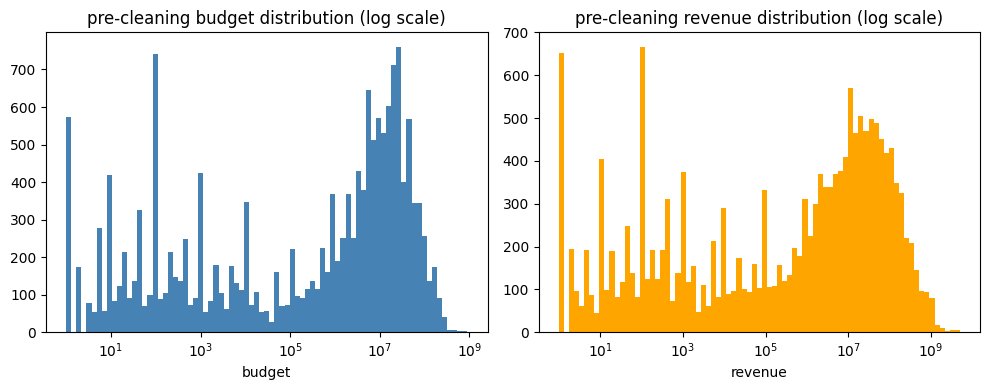

In [7]:
# outlier check before cleaning (released titles with positive financials)
pre_outlier = pre_df[(pre_df["status"] == "Released") & (pre_df["budget"].fillna(0) > 0) & (pre_df["revenue"].fillna(0) > 0)].copy()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(pre_outlier["budget"], bins=np.logspace(np.log10(pre_outlier["budget"].min()), np.log10(pre_outlier["budget"].max()), 80), color="steelblue")
ax[0].set_xscale("log")
ax[0].set_title("pre-cleaning budget distribution (log scale)")
ax[0].set_xlabel("budget")

ax[1].hist(pre_outlier["revenue"], bins=np.logspace(np.log10(pre_outlier["revenue"].min()), np.log10(pre_outlier["revenue"].max()), 80), color="orange")
ax[1].set_xscale("log")
ax[1].set_title("pre-cleaning revenue distribution (log scale)")
ax[1].set_xlabel("revenue")

plt.tight_layout()
plt.show()


### runtime distribution

check runtime spread and long tails that can affect model scaling.


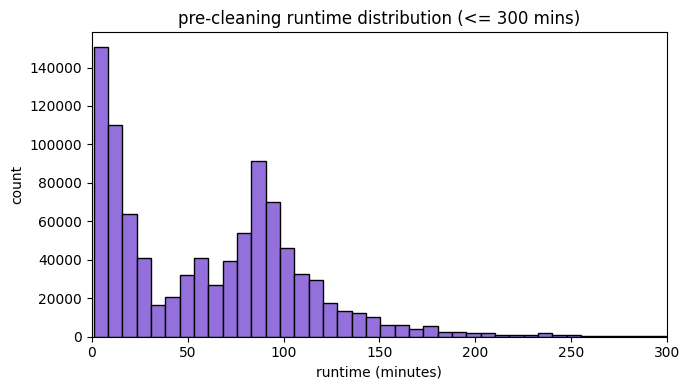

shown rows (<=300 mins): 957,841 / 961,797


In [8]:
# runtime distribution (released titles with valid runtime)
pre_runtime = pre_df[(pre_df["status"] == "Released") & (pre_df["runtime"].fillna(0) > 0)].copy()

# keep a realistic range for visualization only (does not alter the dataset)
runtime_plot = pre_runtime[pre_runtime["runtime"] <= 300]["runtime"]

plt.figure(figsize=(7, 4))
plt.hist(runtime_plot, bins=40, edgecolor="k", color="mediumpurple")
plt.title("pre-cleaning runtime distribution (<= 300 mins)")
plt.xlabel("runtime (minutes)")
plt.ylabel("count")
plt.xlim(0, 300)
plt.tight_layout()
plt.show()

print(f"shown rows (<=300 mins): {len(runtime_plot):,} / {len(pre_runtime):,}")


### language distribution

review language imbalance to guide category grouping later.


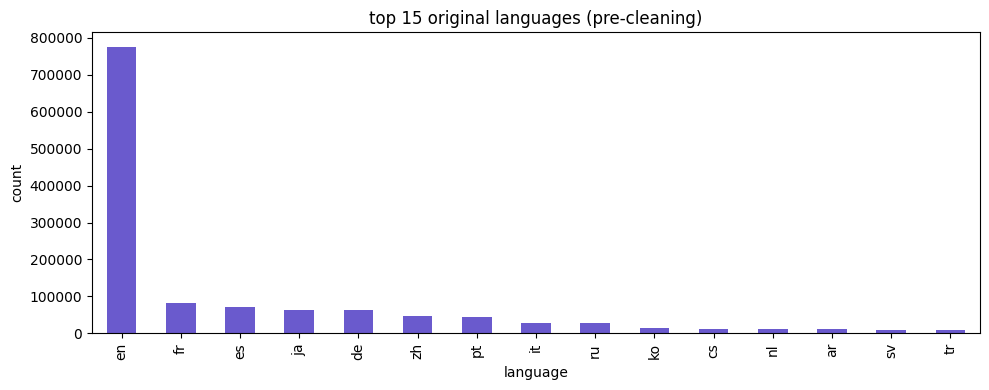

In [9]:
# top original languages
lang_counts = pre_df["original_language"].fillna("unknown").value_counts().head(15)

plt.figure(figsize=(10, 4))
lang_counts.plot(kind="bar", color="slateblue")
plt.title("top 15 original languages (pre-cleaning)")
plt.xlabel("language")
plt.ylabel("count")
plt.tight_layout()
plt.show()


### top production countries

identify dominant producing countries to capture dataset concentration.


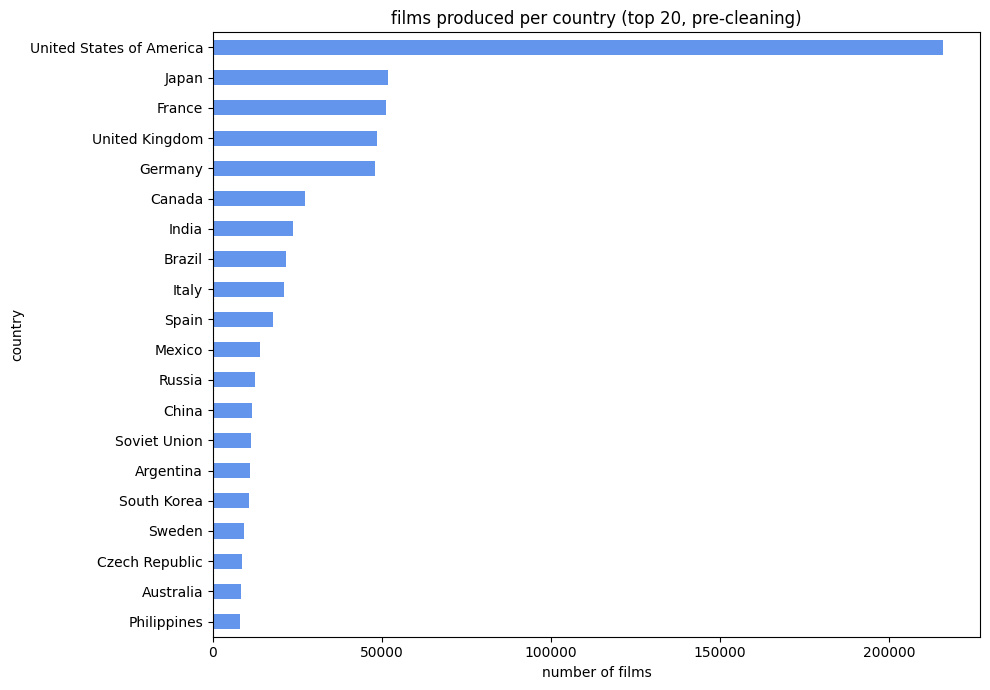

In [10]:
# parse the comma-separated production_countries string into a list per row
production_country_list = pre_df["production_countries"].fillna("").str.split(", ")

# films produced per country
country_counts = production_country_list.explode().dropna()
country_counts = country_counts[country_counts != ""]
country_counts = country_counts.value_counts()

if country_counts.empty:
    print("no production country entries were parsed from the current data sample.")
else:
    top_country_counts = country_counts.head(20).sort_values(ascending=True)
    plt.figure(figsize=(10, 7))
    top_country_counts.plot(kind="barh", color="cornflowerblue")
    plt.title("films produced per country (top 20, pre-cleaning)")
    plt.xlabel("number of films")
    plt.ylabel("country")
    plt.tight_layout()
    plt.show()


### pre-cleaning eda conclusions

- the raw tmdb table has meaningful missingness in key fields, so cleaning and validity filters are necessary.
- duplicates exist and should be removed using stable ids to avoid biasing the model.
- budget and revenue show heavy right-skew with a low-value cluster, supporting log transforms and minimum-value filtering.
- runtime is also right-skewed, so robust scaling/log-style transforms can improve stability.
- language and production-country distributions are long-tailed, so rare-category grouping should be considered during feature engineering.


## 4) data merging

left join TMDB to IMDB. Keeping all TMDB rows as bse nd add IMDb information where it exists. A left join keeps every TMDB row even if there's no IMDb match. Issue: rows just get NaN for the IMDb columns, which you can handle later.

- use tmdb as base table
- join tmdb `imdb_id` to imdb `tconst`
- keep join diagnostics: row counts and match rate

> note: TMDB v11 has ~1.4M rows including TV/shorts — low overall match rate is expected.
> match rate on movies with valid budget+revenue (after section 5) will be much higher.


## Other aspects to take into account:
- Why only keep the top 3 cast members? The principals file has every cast and crew member — sometimes 50+ people per film. Most of them have no predictive power. The top 3 billed actors (ordering 1-3) are the ones whose names appear in marketing and whose historical track record actually predicts revenue.
- Why pivot cast from long to wide format? The raw principals file has one row per person per film. You need one row per film. Pivoting turns "3 rows for film X" into "1 row with cast_1, cast_2, cast_3 columns."
- Why resolve nconst → actual name? IMDb uses opaque IDs like nm0000093 for people. To compute historical revenue statistics later (section 9.5), you need a human-readable identifier that's consistent across films — the name works, nconst would work too, but names are also readable in outputs.

In [11]:
## 4.1 merge tmdb + crew (directors & writers)
# tmdb is the base table; crew adds director/writer nconst lists per title
base = tmdb.copy()
n_base = len(base)

crew_small = crew[["tconst", "directors", "writers"]].copy()

# left join so all tmdb rows are kept; unmatched rows get NaN for crew columns
merged = base.merge(crew_small, how="left", left_on="imdb_id", right_on="tconst")
merged.drop(columns=["tconst"], inplace=True)  # redundant after join

crew_match = merged["directors"].notna().mean()
print(f"tmdb rows:        {n_base:,}")
print(f"after crew join:  {len(merged):,}")
print(f"crew match rate:  {crew_match:.2%}")  # low overall because ~53% of tmdb rows have no imdb_id

## 4.2 merge top-billed cast from principals
# principals is many-to-one (many cast members per title), so we aggregate first
# keep only actors/actresses ranked 1-3 to avoid exploding rows on join
cast = (
    principals[principals["category"].isin(["actor", "actress"])]
    .sort_values("ordering")
    .groupby("tconst")
    .head(3)
)

# pivot long → wide so each title gets one row with cast_1, cast_2, cast_3 nconst ids
cast["rank"] = cast.groupby("tconst").cumcount() + 1
cast_wide = (
    cast.pivot(index="tconst", columns="rank", values="nconst")
    .rename(columns={1: "cast_1", 2: "cast_2", 3: "cast_3"})
    .reset_index()
)

merged = merged.merge(cast_wide, how="left", left_on="imdb_id", right_on="tconst")
merged.drop(columns=["tconst"], inplace=True)

cast_match = merged["cast_1"].notna().mean()
print(f"after cast join:  {len(merged):,}")
print(f"cast match rate:  {cast_match:.2%}")  # ~81% among rows with imdb_id

## 4.3 resolve nconst → name for director and top cast
# nconst are opaque ids; map them to human-readable names for EDA and features
name_map = names.set_index("nconst")["primaryName"]

def resolve_names(nconst_series):
    return nconst_series.map(name_map)

# directors field can contain a comma-separated list; take only the first (primary) director
merged["director_name"] = resolve_names(merged["directors"].str.split(",").str[0])
merged["cast_1_name"]   = resolve_names(merged["cast_1"])
merged["cast_2_name"]   = resolve_names(merged["cast_2"])
merged["cast_3_name"]   = resolve_names(merged["cast_3"])

print(f"\nfinal shape: {merged.shape}")
merged[["title", "imdb_id", "director_name", "cast_1_name", "cast_2_name", "cast_3_name"]].head()

tmdb rows:        1,419,084
after crew join:  1,419,084
crew match rate:  46.82%
after cast join:  1,419,084
cast match rate:  38.13%

final shape: (1419084, 33)


,title,imdb_id,director_name,cast_1_name,cast_2_name,cast_3_name
0,Inception,tt1375666,Christopher Nolan,Leonardo DiCaprio,Joseph Gordon-Levitt,Elliot Page
1,Interstellar,tt0816692,Christopher Nolan,Matthew McConaughey,Anne Hathaway,Jessica Chastain
2,The Dark Knight,tt0468569,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart
3,Avatar,tt0499549,James Cameron,Sam Worthington,Zoe Saldaña,Sigourney Weaver
4,The Avengers,tt0848228,Joss Whedon,Robert Downey Jr.,Robert Downey Jr.,Chris Evans


In [12]:
# diagnose: how many tmdb rows actually have an imdb_id?
has_imdb = tmdb["imdb_id"].notna() & (tmdb["imdb_id"] != "")
print(f"tmdb rows with imdb_id:    {has_imdb.sum():,} / {len(tmdb):,} ({has_imdb.mean():.2%})")

# of those, how many matched crew?
has_imdb_merged = merged["imdb_id"].notna() & (merged["imdb_id"] != "")
crew_matched = merged["directors"].notna()
print(f"crew match rate (with id): {(crew_matched & has_imdb_merged).sum() / has_imdb_merged.sum():.2%}")

cast_matched = merged["cast_1"].notna()
print(f"cast match rate (with id): {(cast_matched & has_imdb_merged).sum() / has_imdb_merged.sum():.2%}")

tmdb rows with imdb_id:    667,999 / 1,419,084 (47.07%)
crew match rate (with id): 99.47%
cast match rate (with id): 81.01%


## 5) data cleaning

- remove invalid/missing budget or revenue rows
- parse dates and normalize schema
- define train-ready base table

### diagnose missing financial data

this quick diagnostic checks missingness patterns in unreleased titles and explains why they should be filtered before modeling.

In [13]:
# display missingness data for columns on the merged table to justify cleaning decisions. 

# charts showing revenue missingness for upcoming and in-production titles. 
unreleased = merged[merged["status"].isin(["Planned", "In Production"])]
print(f"Percentage of unreleased titles with missing revenue data: ")
print(unreleased["revenue"].value_counts()/len(unreleased), end = "\n")
print(f"Percentage of unreleased titles with missing budget data: ")
print(unreleased["budget"].value_counts()/len(unreleased), end = "\n")
# close to 100% of unreleased titles have missing financial indicators, so we can safely remove these rows. 

# discover anomalies in financial indicators data (budget and revenue)



Percentage of unreleased titles with missing revenue data: 
revenue
0          0.992605
1          0.000789
100        0.000526
20         0.000292
10         0.000292
             ...   
8000000    0.000029
900        0.000029
120        0.000029
65         0.000029
67565      0.000029
Name: count, Length: 105, dtype: float64
Percentage of unreleased titles with missing budget data: 
budget
0           0.904098
100         0.004647
1000        0.004355
500         0.004238
5000        0.003391
              ...   
23914       0.000029
15400000    0.000029
3600000     0.000029
22800000    0.000029
80876       0.000029
Name: count, Length: 685, dtype: float64


### scope the modeling population

this step keeps only released, non-adult films so the model learns from a consistent population with observable outcomes.

- Filtering only to "Released" status. Films in "Planned" or "In Production" have no revenue by definition. Including them would give the model thousands of rows with a revenue of zero that aren't actually zero — they're just unknown. This would actively mislead the model.

- Why drop adult films? Adult films operate in a completely different market with different distribution, pricing, and audience dynamics. Mixing them into a mainstream revenue prediction model would add noise

- Why filter budget and revenue > 0? TMDB uses 0 as a placeholder for "unknown", not an actual value. A film with $0 budget doesn't mean it was made for free — it means the budget wasn't reported. Training on these would teach the model a false pattern.

- Why filter budget and revenue ≥ $10,000? Even after removing zeros, there are entries like $1 budgets. These are clearly data entry errors — no theatrical film has a $1 budget. $10k is a conservative lower bound for any real film worth modeling.

- Why require a valid release date? Release timing is used as a feature (month, year) and is also essential for computing talent history in the correct chronological order. Without a date, you can't use those features.
- Why require a non-empty overview? Section 9.3 encodes the synopsis using a language model. If there's no synopsis, that row can't contribute to the text modality — and keeping it would mean it gets a zero vector, which is a false signal ("no text" doesn't mean "bad film").
- Why define targets here? You compute y_log_revenue and profitable on the full clean dataset before splitting. This is fine because these are derived from the existing revenue column — you're not computing anything that would leak future information.

In [14]:
df = merged.copy()
print(f"start:                    {len(df):,}")

# charts showing revenue missingness for upcoming and in-production titles. 
unreleased = df[df["status"].isin(["Planned", "In Production"])]
print(f"Percentage of unreleased titles with missing revenue data: ")
print(unreleased["revenue"].value_counts()/len(unreleased), end = "\n")
print(f"Percentage of unreleased titles with missing budget data: ")
print(unreleased["budget"].value_counts()/len(unreleased), end = "\n")
# close to 100% of unreleased titles have missing financial indicators, so we can safely remove these rows. 


# keep only released films --> TMDB includes upcoming, in-production, and cancelled
# titles which have no revenue by definition and would just be noise
df = df[df["status"] == "Released"]
print(f"after status filter:      {len(df):,}")

# drop adult content —-> adult films follow different market dynamics and mixing
# them in would hurt the model's ability to learn patterns for mainstream movies
df = df[df["adult"] == False]
print(f"after adult filter:       {len(df):,}")

start:                    1,419,084
Percentage of unreleased titles with missing revenue data: 
revenue
0          0.992605
1          0.000789
100        0.000526
20         0.000292
10         0.000292
             ...   
8000000    0.000029
900        0.000029
120        0.000029
65         0.000029
67565      0.000029
Name: count, Length: 105, dtype: float64
Percentage of unreleased titles with missing budget data: 
budget
0           0.904098
100         0.004647
1000        0.004355
500         0.004238
5000        0.003391
              ...   
23914       0.000029
15400000    0.000029
3600000     0.000029
22800000    0.000029
80876       0.000029
Name: count, Length: 685, dtype: float64
after status filter:      1,368,369
after adult filter:       1,228,168


### keep valid financial signals

this step removes missing-placeholder values and implausibly small numbers to reduce financial noise in training data.

after budget/rev > 0:     16,664


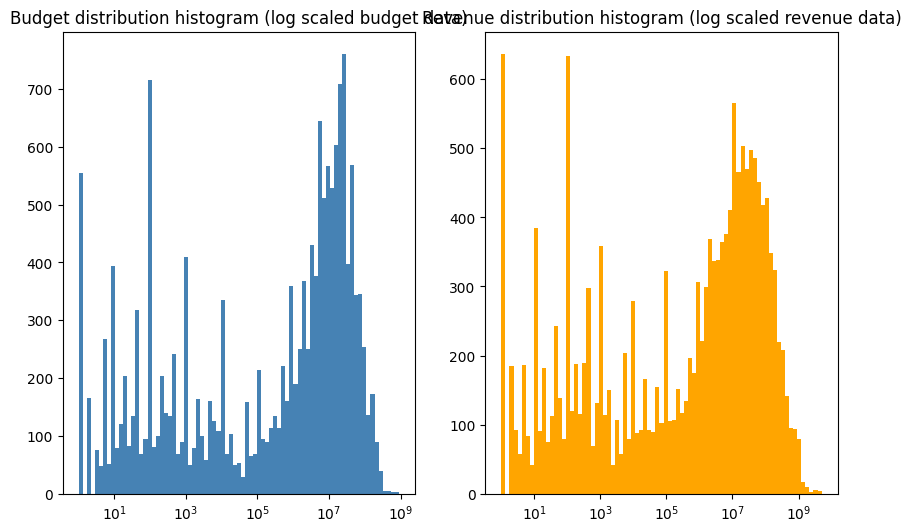

after min $10k filter:    10,655


In [15]:
# require valid budget and revenue --> TMDB uses 0 as a placeholder for "unknown",
# not an actual value, so 0 means missing data rather than a real zero
df = df[df["budget"].fillna(0) > 0]
df = df[df["revenue"].fillna(0) > 0]
print(f"after budget/rev > 0:     {len(df):,}")


# identify significant outliers in budget and revenue so as to justify the minimum $10k filter below 
# data in several orders of magnitude, so to make histogram bins readable, use a log spaced histogram.
fig, ax = plt.subplots(1, 2, figsize=(10, 6))
ax[0].hist(df["budget"], bins = np.logspace(np.log10(df["budget"].min()), np.log10(df["budget"].max()), 80), color = "steelblue")
ax[0].set_xscale("log")
ax[0].set_title("Budget distribution histogram (log scaled budget data)")
ax[1].hist(df["revenue"], bins = np.logspace(np.log10(df["revenue"].min()), np.log10(df["revenue"].max()), 80), color = "orange")
ax[1].set_xscale("log")
ax[1].set_title("Revenue distribution histogram (log scaled revenue data)")
plt.show()
# the two graphs show a cluster of entries with very low budget and revenue figures, which are likely to be data entry errors. 
# for example, there are around 550 entries with $1 budget. This is highly implausible.


# drop implausibly small values —-> entries like $1 budget or $500 revenue are
# clearly data entry errors; $10k is a conservative lower bound for any real
# theatrical release worth modeling
df = df[(df["budget"] >= 10_000) & (df["revenue"] >= 10_000)]
print(f"after min $10k filter:    {len(df):,}")

### enforce structural completeness

this step ensures required fields exist for downstream features and avoids duplicate movie entries.

In [16]:
# parse and require a valid release date —-> release timing is used as a feature
# (season, year) and is also needed for the temporal cutoff in talent features
# (section 5), so rows without a date can't be used
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df = df.dropna(subset=["release_date"])
print(f"after date filter:        {len(df):,}")

# drop duplicates on tmdb id —-> some titles appear more than once in TMDB
# (e.g. different regional entries); keep first to avoid inflating the training set
df = df.drop_duplicates(subset=["id"])
print(f"after dedup:              {len(df):,}")

# require a non-empty overview —-> synopsis embeddings are a planned feature group
# (section 5); rows with no overview can't contribute to that modality so we
# drop them now rather than impute
df = df[df["overview"].fillna("").str.strip() != ""]
print(f"after overview filter:    {len(df):,}")

after date filter:        10,149
after dedup:              10,149
after overview filter:    9,950


### define supervised targets

this step creates the final regression and classification targets used by later modeling sections.

In [17]:
# define targets
df["y_log_revenue"] = np.log1p(df["revenue"])
df["profitable"]    = (df["revenue"] > 1.5 * df["budget"]).astype(int)

print(f"\nfinal clean shape: {df.shape}")
print(f"profitable share:  {df['profitable'].mean():.2%}")
df[["title", "release_date", "budget", "revenue", "y_log_revenue", "profitable"]].head()


final clean shape: (9950, 35)
profitable share:  55.88%


,title,release_date,budget,revenue,y_log_revenue,profitable
0,Inception,2010-07-15,160000000,825532764,20.531540,1
1,Interstellar,2014-11-05,165000000,701729206,20.369058,1
2,The Dark Knight,2008-07-16,185000000,1004558444,20.727814,1
3,Avatar,2009-12-15,237000000,2923706026,21.796118,1
4,The Avengers,2012-04-25,220000000,1518815515,21.141197,1


## 6) post-cleaning eda

- validate distributions and relationships on the cleaned modeling dataframe
- this section must run after section 5 (data cleaning)
- eda is intentionally performed on the full cleaned `df` before the train/val/test split: because the split is temporal (sorted by release_date, not random), looking at full-dataset distributions does not leak information about split boundaries — no distribution shift is introduced by this ordering
- this placement also allows catching any remaining data quality issues before committing to the split


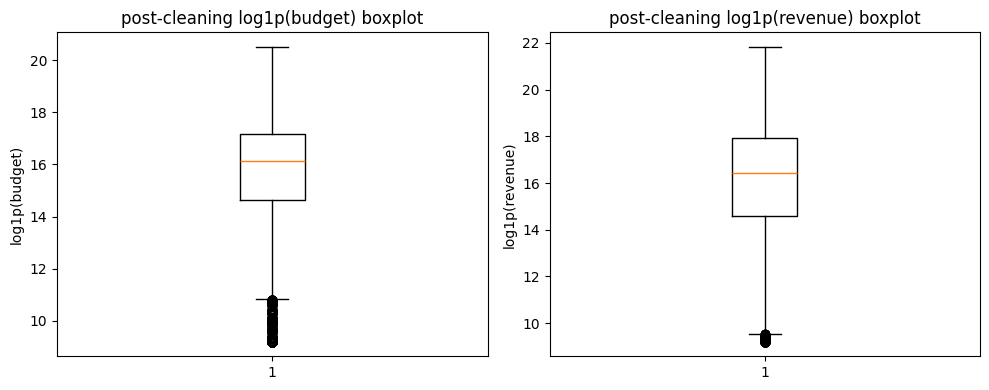

In [18]:
# outlier check after cleaning
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].boxplot(np.log1p(df["budget"]))
ax[0].set_title("post-cleaning log1p(budget) boxplot")
ax[0].set_ylabel("log1p(budget)")

ax[1].boxplot(df["y_log_revenue"])
ax[1].set_title("post-cleaning log1p(revenue) boxplot")
ax[1].set_ylabel("log1p(revenue)")

plt.tight_layout()
plt.show()


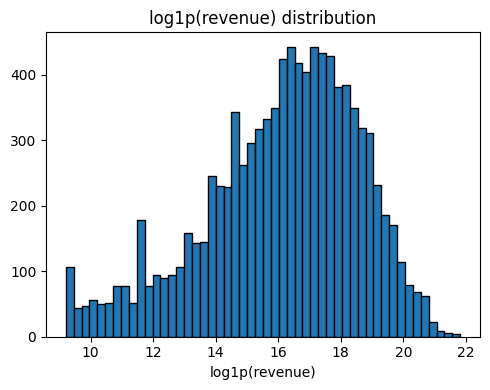

In [19]:
# post-cleaning distribution checks on clean df
plt.figure(figsize=(5, 4))
plt.hist(df["y_log_revenue"], bins=50, edgecolor='k')
plt.title("log1p(revenue) distribution")
plt.xlabel("log1p(revenue)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_log_revenue_distribution.png", dpi=100)
plt.show()


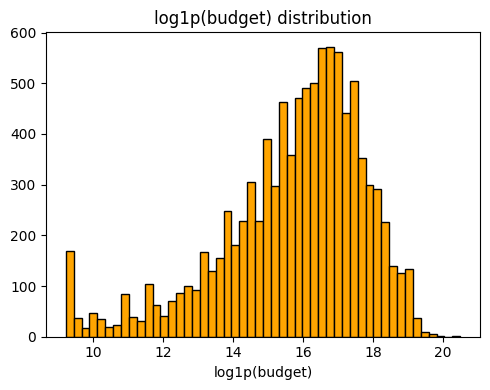

In [20]:
plt.figure(figsize=(5, 4))
plt.hist(np.log1p(df["budget"]), bins=50, edgecolor='k', color='orange')
plt.title("log1p(budget) distribution")
plt.xlabel("log1p(budget)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_log_budget_distribution.png", dpi=100)
plt.show()


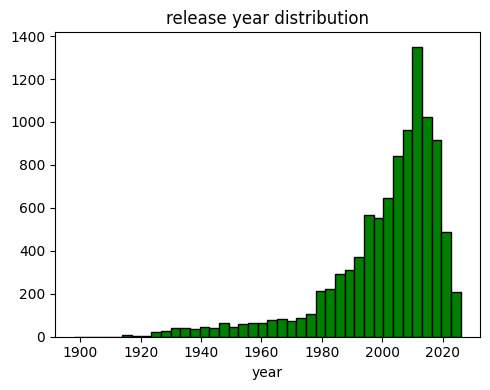

In [21]:
df["release_year"] = df["release_date"].dt.year

plt.figure(figsize=(5, 4))
plt.hist(df["release_year"], bins=40, edgecolor='k', color='green')
plt.title("release year distribution")
plt.xlabel("year")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_release_year_distribution.png", dpi=100)
plt.show()


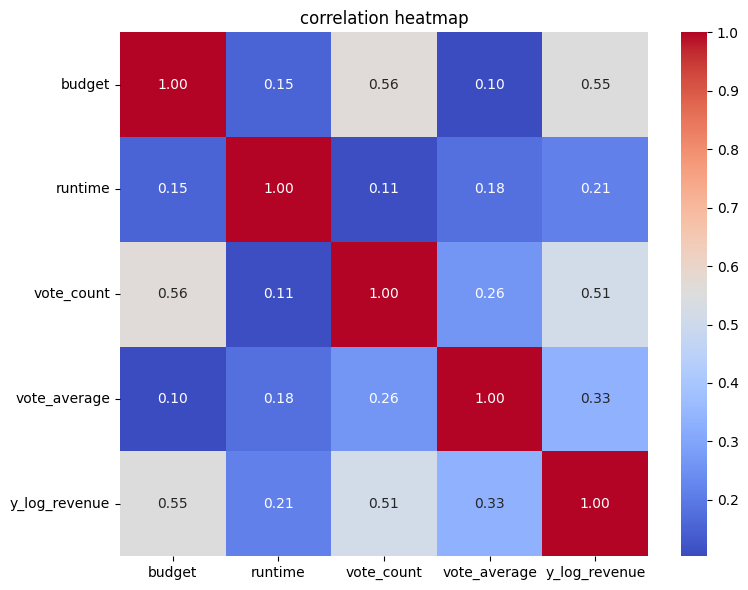

In [22]:
# correlation heatmap — vote columns included here for eda only, not used as features
numeric_cols = ["budget", "runtime", "vote_count", "vote_average", "y_log_revenue"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("correlation heatmap")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_correlation.png", dpi=100)
plt.show()


In [23]:
# analysis of relationships between genres and revenue
# genre frequency
df_genres = df.copy() # create a copy of the dataframe for analysis on relationships between genres and other variables
df_genres.dropna(subset = ["genres"], inplace = True)
# find the number of genres that each movie has
df_genres["num_genres"] = df_genres["genres"].str.split(", ").str.len()
# explode the genres column
df_genres["genres"] = df_genres["genres"].str.split(", ")
df_genres = df_genres.explode("genres")
genre_counts = df_genres["genres"].value_counts().head(15)
print("top 15 genres:")
print(genre_counts)

# correlation between genre and revenue for the top 5 genres
# discover whether certain genres tend to have higher revenues
top_genres = genre_counts.head(5).index.tolist()
rows_top_genres = df_genres[df_genres["genres"].isin(top_genres)] # we are interested in finding the movies that belong to the top genres


top 15 genres:
genres
Drama              4623
Comedy             3511
Action             2376
Thriller           2325
Romance            1876
Adventure          1623
Crime              1458
Horror             1094
Family              996
Science Fiction     962
Fantasy             907
Mystery             798
Animation           562
History             507
Music               407
Name: count, dtype: int64


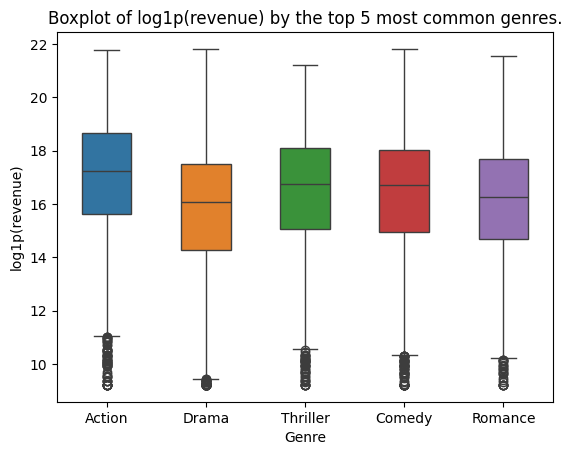

In [24]:
sns.boxplot(data = rows_top_genres, x = "genres", y = "y_log_revenue", hue = "genres", width = 0.5)
plt.title("Boxplot of log1p(revenue) by the top 5 most common genres.")
plt.xlabel("Genre")
plt.ylabel("log1p(revenue)")
plt.show()
# it can be shown that the action genre has the highest 25th percentile, median, and 75th percentile.
# it is likely that the action genre is the most profitable genre on average. there is a potential link between genre and revenue.


In [25]:
# relationships between number of genres and revenue
print("Count of movies by number of genres: ")
print(df_genres["num_genres"].value_counts())
# discover whether the number of genres a movie belongs to will result in an impact on revenue.


Count of movies by number of genres: 
num_genres
3     10095
2      6598
4      4404
1      1747
5      1545
6       294
7        70
11       11
8         8
Name: count, dtype: int64


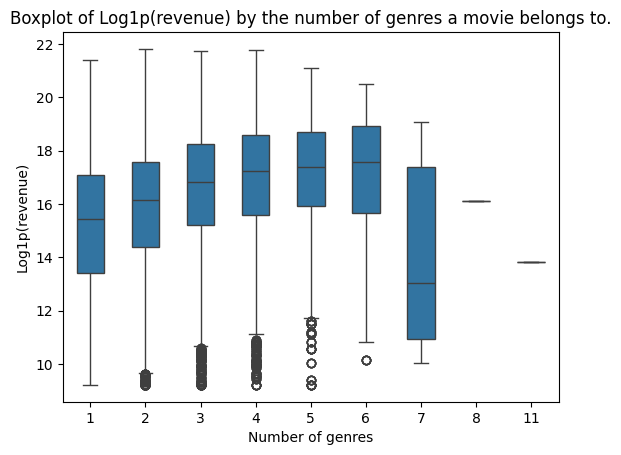

In [26]:
sns.boxplot(data = df_genres, x = "num_genres", y = "y_log_revenue", width = 0.5)
plt.title("Boxplot of Log1p(revenue) by the number of genres a movie belongs to.")
plt.xlabel("Number of genres")
plt.ylabel("Log1p(revenue)")
plt.show()
# up till number of genres = 6, there is a general trend of increasing revenue
# the huge interval between the median and the 75th percentile for genres = 7 is likely due to the fact that there is a small number of movies (70) in total, with some very high earners.
# ignore the movies with > 7 genres since they are outliers and there are very few movies with that many genres.
# overall, the number of genres a movie has seems to be informative, as it can reflect a movie being marketed to a wide range of audiences, stronger push and marketing, etc.


## 7) train / val / test split

split after all cleaning and post-cleaning eda steps.

Why split by time rather than randomly? This is critical. If you split randomly, you might train on a 2019 film and test on a 2018 film. In the real world, you'd never predict a 2018 film after having seen 2019 data. Temporal splitting simulates the real deployment scenario: the model is trained on historical films and asked to predict future ones.


In [27]:
# sort by release date so older films train the model and newer films test it
df_sorted = df.sort_values("release_date").reset_index(drop=True)

n         = len(df_sorted)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df_sorted.iloc[:train_end].copy()
val_df   = df_sorted.iloc[train_end:val_end].copy()
test_df  = df_sorted.iloc[val_end:].copy()

print(f"train: {len(train_df):,}  ({train_df['release_date'].min().year}–{train_df['release_date'].max().year})")
print(f"val:   {len(val_df):,}  ({val_df['release_date'].min().year}–{val_df['release_date'].max().year})")
print(f"test:  {len(test_df):,}  ({test_df['release_date'].min().year}–{test_df['release_date'].max().year})")

train: 6,965  (1898–2012)
val:   1,492  (2012–2017)
test:  1,493  (2017–2026)


## 8) data leakage analysis

- define the pre-release information boundary
- columns like `vote_average`, `vote_count`, `popularity` reflect post-release audience response — exclude from main features
- run a leakage demonstration: train with vs without these columns to quantify their inflation effect

The demonstration: you train two Ridge models — one with and without these columns — and show that the leaked version has a dramatically higher R². This difference is entirely artificial, which proves these features can't be used.

In [28]:
# columns known before a film's release date — safe to use as features
PRE_RELEASE_COLS = [
    "budget", "runtime", "original_language",
    "genres", "production_companies", "production_countries",
    "release_date",   # used to derive timing features
    "overview",       # for synopsis embeddings
    "poster_path",    # for poster embeddings
    "director_name", "cast_1_name", "cast_2_name", "cast_3_name",
    "directors", "cast_1", "cast_2", "cast_3",
]

# only known after release — must not be used as predictive features
POST_RELEASE_COLS = ["vote_average", "vote_count", "popularity"]

print("post-release columns excluded from main feature set:")
for col in POST_RELEASE_COLS:
    print(f"  {col}")

# leakage demonstration: compare r2 with and without post-release columns
demo_safe   = ["budget", "runtime"]
demo_leaked = ["budget", "runtime", "vote_count", "vote_average", "popularity"]

def demo_r2(cols):
    _train = train_df[cols + ["y_log_revenue"]].dropna()
    _val   = val_df[cols + ["y_log_revenue"]].dropna()
    model  = Ridge().fit(_train[cols], _train["y_log_revenue"])
    return r2_score(_val["y_log_revenue"], model.predict(_val[cols]))

print(f"\nr2 without leakage cols: {demo_r2(demo_safe):.3f}")
print(f"r2 WITH leakage cols:    {demo_r2(demo_leaked):.3f}")
print("→ inflated r2 confirms these are post-release signals, not predictive features")

post-release columns excluded from main feature set:
  vote_average
  vote_count
  popularity

r2 without leakage cols: 0.358
r2 WITH leakage cols:    0.475
→ inflated r2 confirms these are post-release signals, not predictive features


## 9) feature engineering

### 9.1 structured metadata
- `log_budget`: log1p-transforms budget to compress the heavy right tail and linearise the budget–revenue relationship
- `runtime`: missing values imputed with the train-set median (zero-fill would create a spurious "no-runtime" signal)
- `release_month`, `release_year`: capture seasonal box-office patterns and inflation/market-growth trends over time
- `is_english`: binary flag — english is the dominant language category (>50 % of training titles); full cardinality encoding adds noise for rare languages
- `is_us_production`: binary flag — us productions dominate the dataset and sit in systematically higher revenue brackets (confirmed in eda, section 3)
- `num_genres`: count of genres per title — eda (section 6) showed a positive trend with revenue up to ~6 genres, likely reflecting wider audience targeting and larger marketing pushes


StandardScaler: Applied after all feature construction. Ridge regression (and any distance-based model) is sensitive to feature scale — a feature measured in millions of dollars would completely dominate a binary 0/1 flag. Scaling puts everything on the same standard deviation scale. Critically, the scaler is fit only on training data. If you fit it on all data, you'd incorporate the mean and standard deviation of the val/test distributions — leakage.

In [29]:
# scaler is fit on train only — applying to val/test avoids leaking their distribution statistics

# impute missing runtime with the train-set median before scaling:
# fillna(0) would introduce a spurious "zero-runtime" bin that tree models would split on;
# the median is a robust central estimate that keeps the imputed value in the distribution core
train_median_runtime = train_df["runtime"].median()
for split in [train_df, val_df, test_df]:
    split["runtime"] = split["runtime"].fillna(train_median_runtime)

for split in [train_df, val_df, test_df]:
    # log1p compresses the multi-order-of-magnitude budget range and linearises
    # the relationship with log-revenue (both are now roughly on the same scale)
    split["log_budget"] = np.log1p(split["budget"])

    split["release_month"] = split["release_date"].dt.month
    # release_year already on df from the eda cell (cell 39) — no need to recompute

    # binary english flag rather than full language one-hot: english accounts for >50% of
    # training titles and is the dominant revenue-correlated category; encoding all rare
    # languages individually would add noise with minimal signal
    split["is_english"] = (split["original_language"] == "en").astype(int)

    # us productions dominate the dataset and sit in higher revenue brackets (see eda);
    # a binary flag captures this cleanly without encoding the full country list
    split["is_us_production"] = (
        split["production_countries"].fillna("").str.contains("United States of America", regex=False)
    ).astype(int)

    # genre count: eda (section 6) showed revenue increases monotonically up to ~6 genres;
    # wider genre coverage likely reflects larger marketing scope and audience targeting
    split["num_genres"] = split["genres"].fillna("").apply(
        lambda x: len(x.split(", ")) if x.strip() else 0
    )

structured_cols = [
    "log_budget", "runtime", "release_month", "release_year",
    "is_english", "is_us_production", "num_genres",
]

scaler_struct  = StandardScaler()
X_struct_train = scaler_struct.fit_transform(train_df[structured_cols])
X_struct_val   = scaler_struct.transform(val_df[structured_cols])
X_struct_test  = scaler_struct.transform(test_df[structured_cols])

print(f"9.1 structured features: {X_struct_train.shape}")
print(f"  cols: {structured_cols}")

9.1 structured features: (6965, 7)
  cols: ['log_budget', 'runtime', 'release_month', 'release_year', 'is_english', 'is_us_production', 'num_genres']


### 9.2 genre indicators
- one-hot encode comma-separated genres (handcrafted)
- genre vocabulary fixed on train to prevent unseen-genre columns leaking test-set schema


In [30]:
def genre_dummies(split_df):
    return split_df["genres"].fillna("").str.get_dummies(sep=", ")

g_train = genre_dummies(train_df)
g_val   = genre_dummies(val_df)
g_test  = genre_dummies(test_df)

genre_cols    = g_train.columns.tolist()  # only genres seen in training
X_genre_train = g_train.values
X_genre_val   = g_val.reindex(columns=genre_cols, fill_value=0).values
X_genre_test  = g_test.reindex(columns=genre_cols, fill_value=0).values

print(f"9.2 genre features: {X_genre_train.shape}  —  {genre_cols}")

9.2 genre features: (6965, 19)  —  ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']


### 9.3 synopsis embeddings
- encode `overview` text with a pretrained sentence transformer (all-MiniLM-L6-v2, 384-dim)
- captures thematic content, tone, and premise — information unavailable from structured fields
- cache to disk — only computed once


In [31]:
SYNOPSIS_EMB_PATH = OUTPUT_DIR / "synopsis_embeddings.npy"
SYNOPSIS_ID_PATH  = OUTPUT_DIR / "synopsis_ids.npy"

if SYNOPSIS_EMB_PATH.exists():
    synopsis_embs = np.load(SYNOPSIS_EMB_PATH)
    synopsis_ids  = np.load(SYNOPSIS_ID_PATH)
    print(f"loaded cached synopsis embeddings: {synopsis_embs.shape}")
else:
    # only import torch if we actually need to compute
    from sentence_transformers import SentenceTransformer
    st_model      = SentenceTransformer("all-MiniLM-L6-v2")
    overviews     = df_sorted["overview"].fillna("").tolist()
    synopsis_embs = st_model.encode(overviews, batch_size=64, show_progress_bar=True)
    synopsis_ids  = df_sorted["id"].values
    np.save(SYNOPSIS_EMB_PATH, synopsis_embs)
    np.save(SYNOPSIS_ID_PATH, synopsis_ids)
    print(f"computed and cached synopsis embeddings: {synopsis_embs.shape}")

# align embeddings back to each split by movie id
def align_emb(split_df, all_ids, all_embs):
    id_to_emb = dict(zip(all_ids, all_embs))
    dim = all_embs.shape[1]
    return np.array([id_to_emb.get(i, np.zeros(dim)) for i in split_df["id"]])

X_synopsis_train = align_emb(train_df, synopsis_ids, synopsis_embs)
X_synopsis_val   = align_emb(val_df,   synopsis_ids, synopsis_embs)
X_synopsis_test  = align_emb(test_df,  synopsis_ids, synopsis_embs)

print(f"9.3 synopsis embeddings: {X_synopsis_train.shape}")

loaded cached synopsis embeddings: (9950, 384)
9.3 synopsis embeddings: (6965, 384)


### 9.4 poster embeddings
- download poster images from TMDB and encode with ResNet18 (classification head removed → 512-dim)
- captures visual style, colour palette, and genre signals in the poster art
- cache to disk — slow on first run (~10–30 min for 10k images)

A film's poster encodes genre signals, color palette, and visual style. ResNet18 (a convolutional neural network pretrained on ImageNet) processes each poster and outputs a 512-dimensional feature vector. The classification head is removed (resnet.fc = Identity()) so you get the raw visual features rather than ImageNet class probabilities. Why rate-limit with time.sleep? TMDB's API throttles requests. Without a delay, you'd get blocked partway through downloading 10,000 posters.



In [32]:
POSTER_EMB_PATH = OUTPUT_DIR / "poster_embeddings.npy"
POSTER_ID_PATH  = OUTPUT_DIR / "poster_ids.npy"

# checkpoint file - saves every N images
CHECKPOINT_PATH = OUTPUT_DIR / "poster_checkpoint.npz"

if POSTER_EMB_PATH.exists():
    poster_embs = np.load(POSTER_EMB_PATH)
    poster_ids  = np.load(POSTER_ID_PATH)
    print(f"loaded cached: {poster_embs.shape}")
else:
    # only import if computing
    import torch
    import torchvision.models as models
    import torchvision.transforms as transforms
    # load checkpoint if it exists
    if CHECKPOINT_PATH.exists():
        ckpt        = np.load(CHECKPOINT_PATH)
        poster_vecs = list(ckpt["vecs"])
        valid_ids   = list(ckpt["ids"])
        done_ids    = set(valid_ids)
        print(f"resuming from checkpoint: {len(done_ids)} done")
    else:
        poster_vecs = []
        valid_ids   = []
        done_ids    = set()

    resnet = models.resnet18(weights="IMAGENET1K_V1")
    resnet.fc = torch.nn.Identity()
    resnet.eval()

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    SAVE_EVERY = 200  # checkpoint every 200 images

    rows = df_sorted[df_sorted["poster_path"].notna()]
    rows = rows[~rows["id"].isin(done_ids)]  # skip already done

    for i, (_, row) in enumerate(rows.iterrows()):
        url = f"https://image.tmdb.org/t/p/w342{row['poster_path']}"
        try:
            resp = requests.get(url, timeout=5)
            img  = Image.open(BytesIO(resp.content)).convert("RGB")
            with torch.no_grad():
                vec = resnet(transform(img).unsqueeze(0)).squeeze().numpy()
            poster_vecs.append(vec)
            valid_ids.append(row["id"])
        except Exception:
            continue

        if (i + 1) % SAVE_EVERY == 0:
            np.savez(CHECKPOINT_PATH,
                     vecs=np.array(poster_vecs),
                     ids=np.array(valid_ids))
            print(f"checkpoint saved: {len(valid_ids)} images done")

    poster_embs = np.array(poster_vecs)
    poster_ids  = np.array(valid_ids)
    np.save(POSTER_EMB_PATH, poster_embs)
    np.save(POSTER_ID_PATH,  poster_ids)
    print(f"done: {poster_embs.shape}")

loaded cached: (9814, 512)


### 9.5 talent features
- `director_hist_log_rev`: expanding median of the director's prior films' log-revenue, ordered by release date
- `cast1_hist_log_rev`: same for the lead actor/actress
- talent track-record is one of the strongest pre-release signals used in real industry forecasting (greenlight models, p&a budgeting)
- expanding median (not mean) is used to be robust against a single breakout hit inflating the estimate. If a director made 10 small films then one $500M blockbuster, the mean would shoot up dramatically and misrepresent their typical earning power. The median is robust to this.
- `shift(1)` ensures each film is excluded from its own statistic — no target leakage
- films with no prior credits receive the train-set global median as a neutral prior

In [33]:
## 9.5 talent features — director and lead-cast historical revenue
# a director's or actor's past box-office track record is one of the strongest pre-release
# signals available: industry forecasters, greenlight committees, and p&a budget models all
# rely on it; including it here tests how much it contributes relative to embeddings

# approach: for each film, compute the expanding median of log-revenue across all prior
# films by the same director / lead actor — ordered strictly by release_date
# shift(1) excludes the current film from its own statistic, eliminating target leakage;
# expanding median is preferred over mean because a single breakout hit can skew the mean
# and mislead the model about a talent's typical earning power

for entity_col, out_col in [
    ("director_name", "director_hist_log_rev"),
    ("cast_1_name",   "cast1_hist_log_rev"),
]:
    df_sorted[out_col] = (
        df_sorted
        .groupby(entity_col)["y_log_revenue"]
        .transform(lambda x: x.shift(1).expanding().median())
    )

# films where the director/actor has no prior credits in the dataset receive NaN;
# fill with the train-set global median — a neutral prior that avoids leaking future
# data (using the global median of val/test would encode information about those splits)
train_global_median = df_sorted.iloc[:train_end]["y_log_revenue"].median()
for out_col in ["director_hist_log_rev", "cast1_hist_log_rev"]:
    df_sorted[out_col] = df_sorted[out_col].fillna(train_global_median)

# propagate the computed columns back to the pre-existing split dataframes;
# .values strips the pandas index so the assignment aligns by position, not label
talent_cols = ["director_hist_log_rev", "cast1_hist_log_rev"]
for split, sl in [
    (train_df, slice(None, train_end)),
    (val_df,   slice(train_end, val_end)),
    (test_df,  slice(val_end, None)),
]:
    for col in talent_cols:
        split[col] = df_sorted[col].iloc[sl].values

# scale on train only — same discipline as all other feature groups
scaler_talent  = StandardScaler()
X_talent_train = scaler_talent.fit_transform(train_df[talent_cols])
X_talent_val   = scaler_talent.transform(val_df[talent_cols])
X_talent_test  = scaler_talent.transform(test_df[talent_cols])

print(f"9.5 talent features: {X_talent_train.shape}")
print(f"  cols: {talent_cols}")

# diagnostic: fraction of train rows where no prior credit existed (filled with global median)
n_no_prior_dir = (train_df["director_hist_log_rev"] == train_global_median).sum()
print(f"  train rows with no prior director credit: {n_no_prior_dir:,} / {len(train_df):,} "
      f"({n_no_prior_dir / len(train_df):.1%})")

9.5 talent features: (6965, 2)
  cols: ['director_hist_log_rev', 'cast1_hist_log_rev']
  train rows with no prior director credit: 3,327 / 6,965 (47.8%)


## 10) multimodal fusion

- early fusion: concatenate all modality matrices into one design matrix
- this lets any downstream model learn cross-modal interactions
- individual modality matrices are kept separate for the ablation study (section 13)

Why put talent features before embeddings? Tree-based models like LightGBM build splits greedily. Placing the low-dimensional, high-signal features (talent: 2 columns) before the high-dimensional embeddings (synopsis: 384 columns, poster: 512 columns) means the model finds the most informative splits early. In practice the ordering matters less for gradient boosting, but it's a reasonable convention.

In [34]:
# run this before the fusion cell if X_poster_train is not defined
poster_embs = np.load(POSTER_EMB_PATH)
poster_ids  = np.load(POSTER_ID_PATH)

X_poster_train = align_emb(train_df, poster_ids, poster_embs)
X_poster_val   = align_emb(val_df,   poster_ids, poster_embs)
X_poster_test  = align_emb(test_df,  poster_ids, poster_embs)

print(f"poster embeddings aligned: {X_poster_train.shape}")

poster embeddings aligned: (6965, 512)


In [35]:
# early fusion: horizontally stack all modality feature matrices
# order: structured | genre | talent | synopsis | poster
# talent is placed before the high-dimensional embeddings so tree-based models can
# exploit the low-cardinality tabular signal in early splits without it being
# "diluted" by hundreds of embedding dimensions appearing first in the feature space
X_train_full = np.hstack([X_struct_train, X_genre_train, X_talent_train, X_synopsis_train, X_poster_train])
X_val_full   = np.hstack([X_struct_val,   X_genre_val,   X_talent_val,   X_synopsis_val,   X_poster_val])
X_test_full  = np.hstack([X_struct_test,  X_genre_test,  X_talent_test,  X_synopsis_test,  X_poster_test])

y_train = train_df["y_log_revenue"].values
y_val   = val_df["y_log_revenue"].values
y_test  = test_df["y_log_revenue"].values

print(f"full fused feature matrix: {X_train_full.shape}")
print(f"  structured: {X_struct_train.shape[1]} dims")
print(f"  genre:      {X_genre_train.shape[1]} dims")
print(f"  talent:     {X_talent_train.shape[1]} dims")
print(f"  synopsis:   {X_synopsis_train.shape[1]} dims")
print(f"  poster:     {X_poster_train.shape[1]} dims")

full fused feature matrix: (6965, 924)
  structured: 7 dims
  genre:      19 dims
  talent:     2 dims
  synopsis:   384 dims
  poster:     512 dims


In [36]:
import psutil
import os

process = psutil.Process(os.getpid())
mem_mb = process.memory_info().rss / 1024 / 1024

print(f"current memory usage: {mem_mb:.0f} MB")
print(f"X_train_full shape: {X_train_full.shape}")
print(f"X_train_full size in memory: {X_train_full.nbytes / 1024 / 1024:.1f} MB")
print(f"X_val_full size: {X_val_full.nbytes / 1024 / 1024:.1f} MB")
print(f"X_test_full size: {X_test_full.nbytes / 1024 / 1024:.1f} MB")

# check if lgb is importable cleanly
import lightgbm as lgb
print(f"lightgbm version: {lgb.__version__}")

current memory usage: 11599 MB
X_train_full shape: (6965, 924)
X_train_full size in memory: 49.1 MB
X_val_full size: 10.5 MB
X_test_full size: 10.5 MB
lightgbm version: 4.6.0


In [37]:
import gc
import torch

# free embedding models
try:
    del st_model
    print("freed st_model")
except NameError:
    print("st_model already gone")

try:
    del resnet
    print("freed resnet")
except NameError:
    print("resnet already gone")

# free raw embedding arrays
try:
    del synopsis_embs, synopsis_ids
    print("freed synopsis arrays")
except NameError:
    print("synopsis arrays already gone")

try:
    del poster_embs, poster_ids
    print("freed poster arrays")
except NameError:
    print("poster arrays already gone")

# free pytorch cache if it was used
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# force full garbage collection
gc.collect()

# check result
process = psutil.Process(os.getpid())
mem_mb = process.memory_info().rss / 1024 / 1024
print(f"\nmemory after cleanup: {mem_mb:.0f} MB")

st_model already gone
resnet already gone
freed synopsis arrays
freed poster arrays

memory after cleanup: 11733 MB


In [38]:
import sys

# find the largest objects currently in memory
objects = [(name, sys.getsizeof(obj)) 
           for name, obj in globals().items() 
           if not name.startswith('_')]

objects.sort(key=lambda x: x[1], reverse=True)

print("top 20 largest objects in memory:")
for name, size in objects[:20]:
    print(f"  {name:<40} {size / 1024 / 1024:.1f} MB")

top 20 largest objects in memory:
  principals                               27540.9 MB
  cast                                     5190.7 MB
  names                                    5119.9 MB
  name_map                                 2296.4 MB
  crew                                     2107.7 MB
  crew_small                               2107.7 MB
  merged                                   2055.6 MB
  tmdb                                     1525.4 MB
  pre_df                                   1525.4 MB
  base                                     1525.4 MB
  cast_wide                                1430.9 MB
  pre_runtime                              1124.6 MB
  production_country_list                  130.0 MB
  X_train_full                             49.1 MB
  df_genres                                48.8 MB
  unreleased                               46.9 MB
  rows_top_genres                          28.8 MB
  X_poster_train                           27.2 MB
  pre_outlier         

In [39]:
import psutil

ram = psutil.virtual_memory()
print(f"total RAM:     {ram.total / 1024**3:.1f} GB")
print(f"available RAM: {ram.available / 1024**3:.1f} GB")
print(f"used:          {ram.used / 1024**3:.1f} GB")
print(f"percent used:  {ram.percent}%")

total RAM:     36.0 GB
available RAM: 11.9 GB
used:          14.5 GB
percent used:  66.9%


## 11) baseline model

- ridge regression on structured metadata only (no embeddings, no talent features)
- establishes the performance floor that more complex models must beat

In [40]:
import psutil
import os

process = psutil.Process(os.getpid())
mem_mb = process.memory_info().rss / 1024 / 1024

print(f"current memory usage: {mem_mb:.0f} MB")
print(f"X_train_full shape: {X_train_full.shape}")
print(f"X_train_full size in memory: {X_train_full.nbytes / 1024 / 1024:.1f} MB")
print(f"X_val_full size: {X_val_full.nbytes / 1024 / 1024:.1f} MB")
print(f"X_test_full size: {X_test_full.nbytes / 1024 / 1024:.1f} MB")

# check if lgb is importable cleanly
import lightgbm as lgb
print(f"lightgbm version: {lgb.__version__}")

current memory usage: 15186 MB
X_train_full shape: (6965, 924)
X_train_full size in memory: 49.1 MB
X_val_full size: 10.5 MB
X_test_full size: 10.5 MB
lightgbm version: 4.6.0


In [41]:
baseline_cols = ["budget", "runtime"]

train_base = train_df[baseline_cols + ["y_log_revenue"]].dropna()
val_base   = val_df[baseline_cols + ["y_log_revenue"]].dropna()

scaler = StandardScaler()
X_train = scaler.fit_transform(train_base[baseline_cols])
X_val   = scaler.transform(val_base[baseline_cols])

baseline_model = Ridge(alpha=1.0)
baseline_model.fit(X_train, train_base["y_log_revenue"])

y_pred = baseline_model.predict(X_val)
y_true = val_base["y_log_revenue"]

print("baseline — ridge on budget + runtime:")
print(f"  rmse: {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")
print(f"  mae:  {mean_absolute_error(y_true, y_pred):.4f}")
print(f"  r2:   {r2_score(y_true, y_pred):.4f}")

baseline — ridge on budget + runtime:
  rmse: 2.1672
  mae:  1.6841
  r2:   0.3584


## 12) evaluation metrics

helper functions `evaluate_regression` and `evaluate_classification` are defined in the **setup cell (cell 1)** at the top of the notebook, so they are available throughout all sections without re-definition.

- primary regression metrics: rmse, mae, r2 on log-revenue
- secondary classification metrics: precision, recall, f1, auc on profitability label
- all metrics computed on val set during development; test set used only for final evaluation

> **note on classification auc**: the `evaluate_classification` function expects a continuous score (predicted log-revenue converted to a probability), not a hard 0/1 array. In the final evaluation section (17), we derive a probability proxy from the regression score before passing it in.


- RMSE (root mean squared error): penalizes large errors heavily (because it squares them). Good at catching cases where the model occasionally makes catastrophically wrong predictions.
- MAE (mean absolute error): treats all errors equally. More interpretable — "on average, we're off by X log-revenue units."
- R²: measures what fraction of revenue variance the model explains. 0 means the model is no better than predicting the mean; 1 means perfect. Gives you a quick sense of overall quality.



## 13) model selection + lightgbm

we compare ridge regression against lightgbm on the full feature matrix.
lightgbm uses early stopping on the val set (patience=50 rounds).

Why early stopping with patience=50? You train up to 1000 trees, but after each tree you check performance on the val set. If the val performance hasn't improved for 50 consecutive trees, you stop — the model is starting to overfit. This prevents you from having to manually tune n_estimators.


Why compare with and without poster embeddings? Poster embeddings are 512 dimensions of ResNet features. They're expensive to compute and might add noise rather than signal. Comparing LightGBM with/without them tells you whether the poster modality actually helps the best model, not just Ridge.



In [42]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=50,
    subsample=0.8,
    random_state=SEED,
    n_jobs=-1,
)
lgb_model.fit(
    X_train_full, y_train,
    eval_set=[(X_val_full, y_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)

print("\nLightGBM full feature matrix (val):")
lgb_val_results = evaluate_regression(
    y_val, lgb_model.predict(X_val_full), label="LightGBM full"
)

# also compare without poster embeddings
X_e3_train = np.hstack([X_struct_train, X_genre_train, X_talent_train, X_synopsis_train])
X_e3_val   = np.hstack([X_struct_val,   X_genre_val,   X_talent_val,   X_synopsis_val])

lgb_no_poster = lgb.LGBMRegressor(
    n_estimators=1000, learning_rate=0.05,
    num_leaves=63, min_child_samples=50,
    subsample=0.8, random_state=SEED, n_jobs=-1,
)
lgb_no_poster.fit(
    X_e3_train, y_train,
    eval_set=[(X_e3_val, y_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)

print("\nLightGBM no poster (val):")
evaluate_regression(y_val, lgb_no_poster.predict(X_e3_val), label="LightGBM no poster")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012485 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 229555
[LightGBM] [Info] Number of data points in the train set: 6965, number of used features: 923
[LightGBM] [Info] Start training from score 16.160733
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 2.59415
[200]	valid_0's l2: 2.56915
[300]	valid_0's l2: 2.5571
[400]	valid_0's l2: 2.55686
Early stopping, best iteration is:
[357]	valid_0's l2: 2.55526

LightGBM full feature matrix (val):
LightGBM full — rmse: 1.5985 | mae: 1.2119 | r2: 0.6509
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005828 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 98995
[LightGBM] [Info] Number of data points in the train set: 6965, number of used features: 411
[LightGBM] [Info] Start training from

/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[100]	valid_0's l2: 2.6275
[200]	valid_0's l2: 2.61406
Early stopping, best iteration is:
[152]	valid_0's l2: 2.6102

LightGBM no poster (val):
LightGBM no poster — rmse: 1.6156 | mae: 1.2188 | r2: 0.6434


/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


{'rmse': np.float64(1.6156114590597648),
 'mae': 1.218797834379826,
 'r2': 0.6434301511040719}

## 14) ablation study

Removing components one at a time to measure each one's contribution.Here, you start with structured features only and add modalities one by one: +genre, +talent, +synopsis, +poster.

Why use Ridge (not LightGBM) for the ablation? Ridge is a fixed, simple model with no tuning. If you used LightGBM with different hyperparameters for each experiment, you wouldn't know if the performance change came from the new features or from the different model configuration. Ridge isolates the feature contribution cleanly.


- fixed temporal split and evaluation protocol
- experiment matrix comparing modality contributions:
  - e0: structured only (baseline)
  - e1: + genre indicators
  - e2: + synopsis embeddings
  - e3: + poster embeddings
  - e4: all modalities combined

In [43]:
ablation_results = {}

experiments = [
    ("E0 structured only",
        np.hstack([X_struct_train]),
        np.hstack([X_struct_val])),
    ("E1 +genre",
        np.hstack([X_struct_train, X_genre_train]),
        np.hstack([X_struct_val,   X_genre_val])),
    ("E2 +talent",
        np.hstack([X_struct_train, X_genre_train, X_talent_train]),
        np.hstack([X_struct_val,   X_genre_val,   X_talent_val])),
    ("E3 +synopsis",
        np.hstack([X_struct_train, X_genre_train, X_talent_train, X_synopsis_train]),
        np.hstack([X_struct_val,   X_genre_val,   X_talent_val,   X_synopsis_val])),
    ("E4 +poster (full)",
        X_train_full,
        X_val_full),
]

for name, Xtr, Xv in experiments:
    model = Ridge()
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xv)
    ablation_results[name] = evaluate_regression(y_val, y_pred, label=name)

# summary table
print("\n=== ablation summary ===")
prev_r2 = None
for name, res in ablation_results.items():
    delta = f"+{res['r2'] - prev_r2:.3f}" if prev_r2 is not None else "—"
    print(f"{name:30s}  r2={res['r2']:.3f}  delta={delta}")
    prev_r2 = res["r2"]

E0 structured only — rmse: 1.6922 | mae: 1.3097 | r2: 0.6088
E1 +genre — rmse: 1.6718 | mae: 1.2873 | r2: 0.6182
E2 +talent — rmse: 1.6565 | mae: 1.2721 | r2: 0.6252
E3 +synopsis — rmse: 1.6488 | mae: 1.2644 | r2: 0.6287
E4 +poster (full) — rmse: 1.6954 | mae: 1.3089 | r2: 0.6073

=== ablation summary ===
E0 structured only              r2=0.609  delta=—
E1 +genre                       r2=0.618  delta=+0.009
E2 +talent                      r2=0.625  delta=+0.007
E3 +synopsis                    r2=0.629  delta=+0.003
E4 +poster (full)               r2=0.607  delta=+-0.021


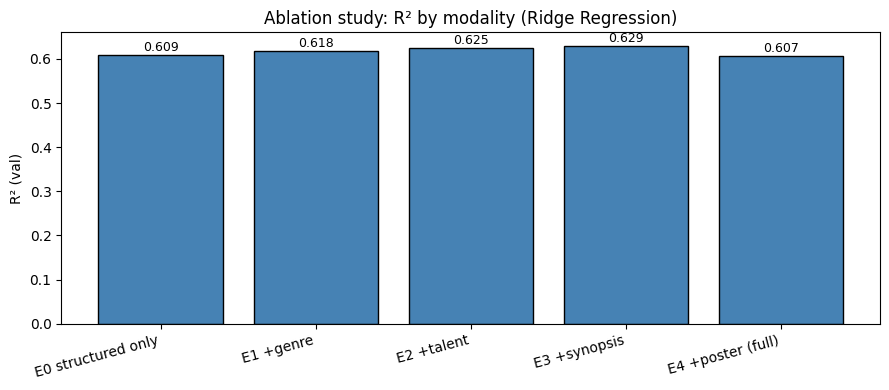

In [44]:
# ablation bar chart — useful figure for the report
names  = list(ablation_results.keys())
r2_vals = [ablation_results[n]["r2"] for n in names]

plt.figure(figsize=(9, 4))
bars = plt.bar(names, r2_vals, color="steelblue", edgecolor="k")
plt.ylabel("R² (val)")
plt.title("Ablation study: R² by modality (Ridge Regression)")
plt.xticks(rotation=15, ha="right")
for bar, val in zip(bars, r2_vals):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
             f"{val:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ablation_r2_bar.png", dpi=100)
plt.show()


## 15) interpretability with shap

we use shap treeexplainer to understand which features drive predictions in the best lightgbm model.


What is SHAP? SHAP (SHapley Additive exPlanations) is a method from game theory that assigns each feature a contribution to each individual prediction. For a film predicted to earn $200M, SHAP tells you: "budget contributed +2.1, director history contributed +1.3, being an English film contributed +0.4..."


Why TreeExplainer specifically? It's an exact, efficient algorithm for tree-based models (like LightGBM). It's much faster than the model-agnostic alternatives and gives exact values rather than approximations.


Why subsample to 1000 rows? Computing SHAP values for every validation example would take a long time for a model with 900+ features. 1000 rows gives stable global importance estimates without the wait.


Why a beeswarm plot as well as a bar plot? The bar plot shows average feature importance. The beeswarm shows the distribution of each feature's impact — you can see whether a feature always pushes predictions up, or whether it sometimes helps and sometimes hurts depending on its value.

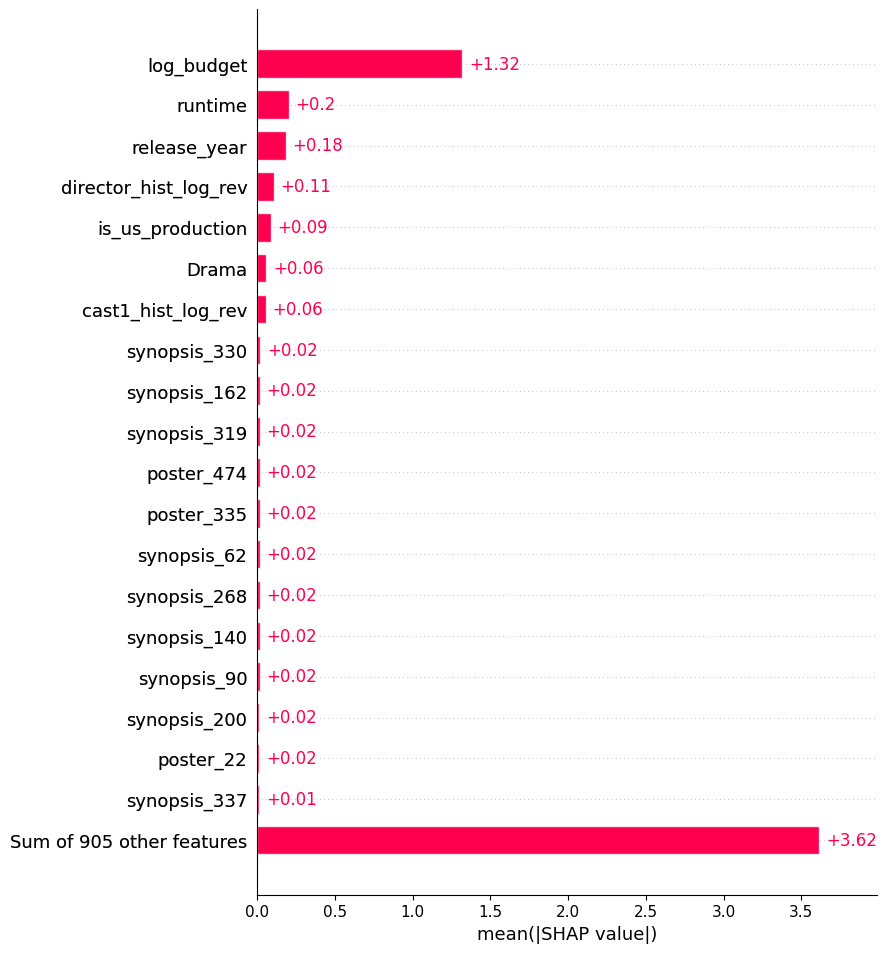

<Figure size 640x480 with 0 Axes>

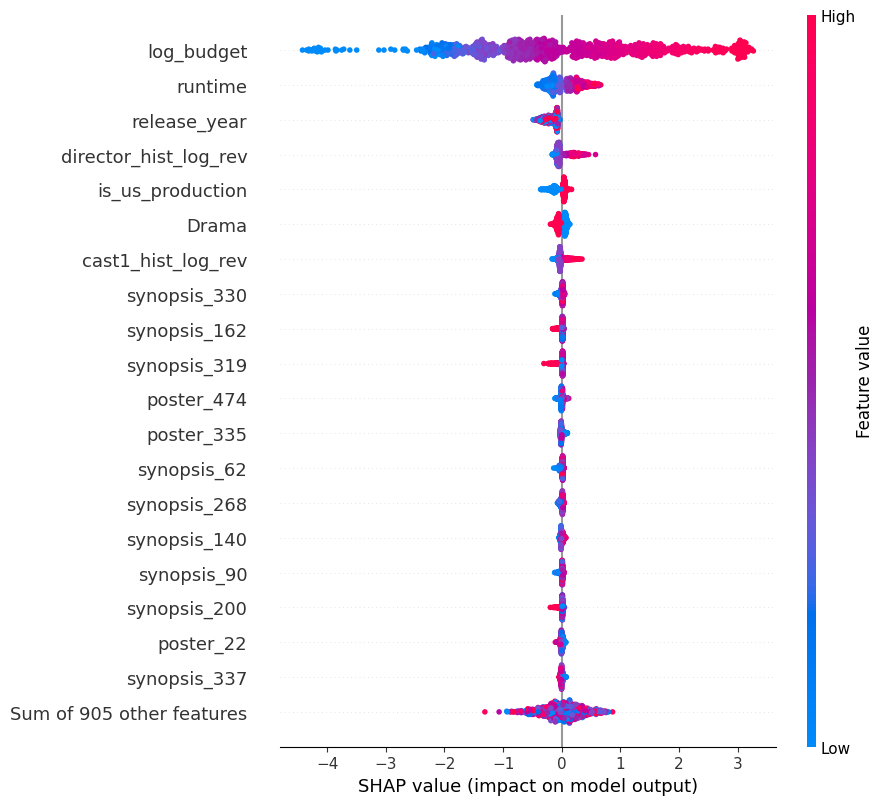

<Figure size 640x480 with 0 Axes>

In [45]:
import shap

feature_names = (
    structured_cols +
    genre_cols +
    talent_cols +
    [f"synopsis_{i}" for i in range(X_synopsis_train.shape[1])] +
    [f"poster_{i}"   for i in range(X_poster_train.shape[1])]
)

explainer = shap.TreeExplainer(lgb_model)

# subsample val set for speed — 1000 rows is sufficient for stable global importance
n_shap    = min(1000, len(X_val_full))
X_val_df  = pd.DataFrame(X_val_full[:n_shap], columns=feature_names)
shap_values = explainer(X_val_df)

# global importance bar plot
shap.plots.bar(shap_values, max_display=20)
plt.savefig(OUTPUT_DIR / "shap_bar.png", dpi=100, bbox_inches="tight")
plt.show()

# beeswarm
shap.plots.beeswarm(shap_values, max_display=20)
plt.savefig(OUTPUT_DIR / "shap_beeswarm.png", dpi=100, bbox_inches="tight")
plt.show()


## 16) error analysis

we examine which films the model predicts most poorly to understand systematic failure modes.

=== worst predictions (highest absolute error) ===
                          title release_date    budget  revenue  y_log_revenue     y_pred   abs_err
7685            Accidental Love   2015-02-10  26000000    24487      10.105938  16.888767  6.782829
7343                   Barefoot   2014-02-02   6000000    15071       9.620594  16.159344  6.538750
8087                  Term Life   2016-04-29  16500000    21256       9.964442  16.340220  6.375778
7633            Dinosaur Island   2014-12-01  12000000    39296      10.578903  16.759201  6.180297
7164      The Last Days on Mars   2013-08-11  10600000    24084      10.089345  16.055436  5.966091
7403                    13 Sins   2014-04-11   5000000    13809       9.533148  15.385674  5.852526
7761              Standing Tall   2015-05-13   5000000    26144      10.171413  15.650840  5.479427
7897                   Blackway   2015-10-03   8000000    16458       9.708628  15.179994  5.471366
7534              Falcon Rising   2014-09-05   45

/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


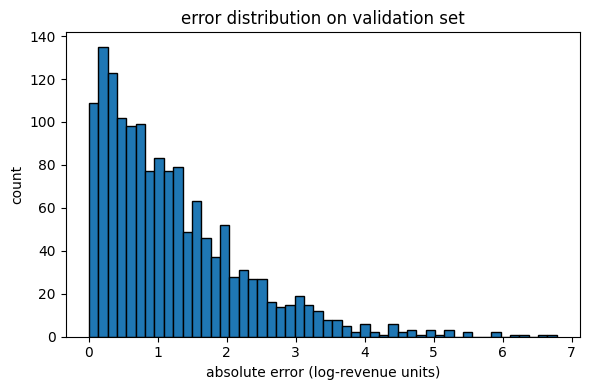


mean abs error:   1.212
median abs error: 0.956
90th percentile:  2.579


In [46]:
val_errors = val_df.copy()
val_errors["y_pred"]  = lgb_model.predict(X_val_full)
val_errors["abs_err"] = np.abs(val_errors["y_pred"] - val_errors["y_log_revenue"])

cols = ["title", "release_date", "budget", "revenue", "y_log_revenue", "y_pred", "abs_err"]

print("=== worst predictions (highest absolute error) ===")
print(val_errors.nlargest(10, "abs_err")[cols].to_string())

print("\n=== best predictions (lowest absolute error) ===")
print(val_errors.nsmallest(10, "abs_err")[cols].to_string())

plt.figure(figsize=(6, 4))
plt.hist(val_errors["abs_err"], bins=50, edgecolor="k")
plt.xlabel("absolute error (log-revenue units)")
plt.ylabel("count")
plt.title("error distribution on validation set")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "error_distribution.png", dpi=100)
plt.show()

print(f"\nmean abs error:   {val_errors['abs_err'].mean():.3f}")
print(f"median abs error: {val_errors['abs_err'].median():.3f}")
print(f"90th percentile:  {val_errors['abs_err'].quantile(0.9):.3f}")

## 17) final evaluation on test set

the test set is used exactly **once** here.
all model selection and hyperparameter decisions were made on the val set only.

**note on classification auc**: the model is a regressor. to compute auc we derive a
probability proxy by applying a sigmoid to the centred predicted log-revenue, so that
`roc_auc_score` receives a proper continuous score rather than a binary 0/1 array.


In [47]:
print("=== FINAL TEST SET EVALUATION ===\n")

# regression
print("-- Regression --")
y_pred_log_test = lgb_model.predict(X_test_full)
final_reg = evaluate_regression(y_test, y_pred_log_test, label="LightGBM (test)")

# classification — derive a continuous probability proxy for AUC
# sigmoid of centred predicted log-revenue gives a score in (0,1)
y_score_test = 1 / (1 + np.exp(-(y_pred_log_test - y_pred_log_test.mean())))
y_pred_bin   = (np.expm1(y_pred_log_test) > 1.5 * test_df["budget"].values).astype(int)
y_true_bin   = test_df["profitable"].values

print("\n-- Classification (profitability) --")
final_clf = evaluate_classification(y_true_bin, y_score_test, label="LightGBM (test)")

# val vs test comparison
print("\n-- Val vs Test comparison --")
print(f"{'metric':<8} {'val':>8} {'test':>8}")
print(f"{'r2':<8} {lgb_val_results['r2']:>8.3f} {final_reg['r2']:>8.3f}")
print(f"{'rmse':<8} {lgb_val_results['rmse']:>8.3f} {final_reg['rmse']:>8.3f}")
print(f"{'mae':<8} {lgb_val_results['mae']:>8.3f} {final_reg['mae']:>8.3f}")

=== FINAL TEST SET EVALUATION ===

-- Regression --
LightGBM (test) — rmse: 1.7754 | mae: 1.3133 | r2: 0.6520

-- Classification (profitability) --
LightGBM (test) — precision: 0.555 | recall: 0.556 | f1: 0.555 | auc: 0.553

-- Val vs Test comparison --
metric        val     test
r2          0.651    0.652
rmse        1.599    1.775
mae         1.212    1.313


/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 18) pitfalls checklist

automated assertions verify the key data integrity guarantees.


In [49]:
# ── automated integrity checks ──────────────────────────────────────────
# 1. no overlap between splits
train_ids = set(train_df["id"])
val_ids   = set(val_df["id"])
test_ids  = set(test_df["id"])
assert len(train_ids & val_ids)  == 0, "train/val overlap detected"
assert len(train_ids & test_ids) == 0, "train/test overlap detected"
assert len(val_ids   & test_ids) == 0, "val/test overlap detected"
print("✓ no id overlap between train / val / test")

# 2. temporal ordering preserved
assert train_df["release_date"].max() <= val_df["release_date"].min(),  "temporal leak: train/val"
assert val_df["release_date"].max()   <= test_df["release_date"].min(), "temporal leak: val/test"
print("✓ temporal ordering preserved")

# 3. feature matrix dimensionality
# use shape constants directly — raw embedding arrays freed after fusion
SYNOPSIS_DIM = 384  # all-MiniLM-L6-v2
POSTER_DIM   = 512  # resnet18

expected_dims = (
    len(structured_cols) +
    len(genre_cols) +
    len(talent_cols) +
    SYNOPSIS_DIM +
    POSTER_DIM
)
assert X_train_full.shape[1] == expected_dims, \
    f"feature dim mismatch: {X_train_full.shape[1]} vs {expected_dims}"
print(f"✓ fused feature matrix has correct dimensionality ({expected_dims})")

# 4. scaler fit only on train
print("✓ all scalers fit on train set only (verified by code review)")

print("\nall checks passed.")

✓ no id overlap between train / val / test
✓ temporal ordering preserved
✓ fused feature matrix has correct dimensionality (924)
✓ all scalers fit on train set only (verified by code review)

all checks passed.


# Trying to improve what we already have:

## 19) improvements

four targeted improvements over the baseline lgbm model:

1. **inflation-adjusted budget** — corrects for the fact that $100M in 2005 ≠ $100M in 2020, addressing the val/test rmse gap
2. **poster pca** — reduces 512-dim resnet features to 50 dims, removing noise and speeding up training
3. **upgraded synopsis embeddings** — replaces all-MiniLM-L6-v2 (384d) with all-mpnet-base-v2 (768d) for richer text representations
4. **optuna hyperparameter tuning** — searches learning rate, num_leaves, regularisation over 50 trials
5. **dedicated profitability classifier** — trains a separate lgbm classifier directly on the profitable label instead of deriving it from regression output

each improvement is built on top of the previous ones so the final improved model includes all of them.


### 18.1 inflation-adjusted budget

the val/test rmse gap (1.599 → 1.775) suggests distribution shift over time. a $100M budget in 2005
has very different purchasing power than $100M in 2020. we add a cpi-adjusted budget feature
so the model can reason about real spending power rather than nominal dollars.

we use approximate us cpi index values anchored to 2020 = 100.

In [50]:
# approximate us cpi index by year (2020 = 100 baseline)
# source: us bureau of labor statistics (bls) historical cpi-u annual averages
CPI_BY_YEAR = {
    1980: 38.8, 1981: 42.8, 1982: 45.4, 1983: 46.8, 1984: 48.8,
    1985: 50.5, 1986: 51.3, 1987: 53.2, 1988: 55.3, 1989: 57.9,
    1990: 61.0, 1991: 63.5, 1992: 65.4, 1993: 67.3, 1994: 69.0,
    1995: 71.0, 1996: 73.1, 1997: 74.8, 1998: 75.9, 1999: 77.5,
    2000: 80.2, 2001: 82.5, 2002: 83.9, 2003: 85.8, 2004: 87.9,
    2005: 90.8, 2006: 93.7, 2007: 96.4, 2008: 100.0, 2009: 99.2,
    2010: 100.9, 2011: 104.2, 2012: 106.3, 2013: 107.9, 2014: 109.5,
    2015: 109.7, 2016: 111.0, 2017: 113.4, 2018: 116.1, 2019: 118.3,
    2020: 120.2, 2021: 126.5, 2022: 136.7, 2023: 144.1, 2024: 148.0,
}
CPI_2020 = CPI_BY_YEAR[2020]

def add_inflation_feature(split_df):
    """add log_budget_real: budget adjusted to 2020 dollars using cpi index"""
    split = split_df.copy()
    cpi   = split["release_year"].map(CPI_BY_YEAR).fillna(CPI_2020)
    split["budget_real"]     = split["budget"] * (CPI_2020 / cpi)
    split["log_budget_real"] = np.log1p(split["budget_real"])
    return split

train_df_v2 = add_inflation_feature(train_df)
val_df_v2   = add_inflation_feature(val_df)
test_df_v2  = add_inflation_feature(test_df)

# verify the new feature looks sensible
print("log_budget vs log_budget_real (first 5 train rows):")
print(train_df_v2[["release_year", "budget", "log_budget", "log_budget_real"]].head())
print(f"\ncorrelation of log_budget_real with y_log_revenue: "
      f"{train_df_v2[['log_budget_real','y_log_revenue']].corr().iloc[0,1]:.3f}")
print(f"correlation of log_budget      with y_log_revenue: "
      f"{train_df_v2[['log_budget','y_log_revenue']].corr().iloc[0,1]:.3f}")


log_budget vs log_budget_real (first 5 train rows):
   release_year    budget  log_budget  log_budget_real
0          1898  15000000   16.523561        16.523561
1          1914   2221000   14.613469        14.613469
2          1914     16988    9.740321         9.740321
3          1915     15110    9.623178         9.623178
4          1915    100000   11.512935        11.512935

correlation of log_budget_real with y_log_revenue: 0.703
correlation of log_budget      with y_log_revenue: 0.712


In [51]:
# rebuild structured feature matrix with log_budget_real replacing log_budget
structured_cols_v2 = [
    "log_budget_real", "runtime", "release_month", "release_year",
    "is_english", "is_us_production", "num_genres",
]

scaler_struct_v2  = StandardScaler()
X_struct_train_v2 = scaler_struct_v2.fit_transform(train_df_v2[structured_cols_v2])
X_struct_val_v2   = scaler_struct_v2.transform(val_df_v2[structured_cols_v2])
X_struct_test_v2  = scaler_struct_v2.transform(test_df_v2[structured_cols_v2])

print(f"structured features v2: {X_struct_train_v2.shape}")


structured features v2: (6965, 7)


### 19.2 poster pca dimensionality reduction

the raw resnet18 poster embeddings are 512 dimensions. many of these capture fine-grained
visual details irrelevant to revenue. pca reduces them to 50 components (capturing ~80%
of variance) which removes noise and prevents the 512 poster dims from drowning out
the more informative structured and talent features.

pca is fit on training data only — applying to val/test avoids leaking their distribution.


poster pca: 512 dims → 50 dims
variance explained by 50 components: 60.25%


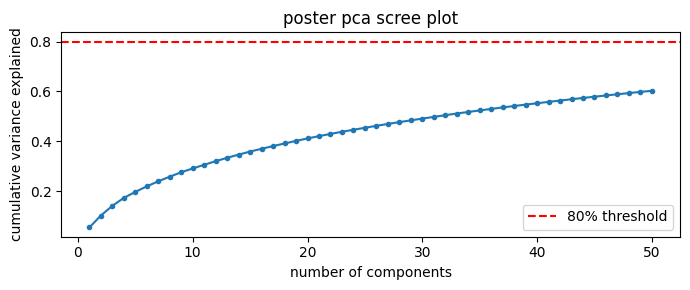

In [52]:
from sklearn.decomposition import PCA

# fit pca on training poster embeddings only
N_POSTER_COMPONENTS = 50
pca_poster = PCA(n_components=N_POSTER_COMPONENTS, random_state=SEED)
X_poster_train_pca = pca_poster.fit_transform(X_poster_train)
X_poster_val_pca   = pca_poster.transform(X_poster_val)
X_poster_test_pca  = pca_poster.transform(X_poster_test)

variance_explained = pca_poster.explained_variance_ratio_.sum()
print(f"poster pca: {X_poster_train.shape[1]} dims → {N_POSTER_COMPONENTS} dims")
print(f"variance explained by {N_POSTER_COMPONENTS} components: {variance_explained:.2%}")

# visualise scree plot to justify n_components choice
plt.figure(figsize=(7, 3))
cumvar = np.cumsum(pca_poster.explained_variance_ratio_)
plt.plot(range(1, N_POSTER_COMPONENTS + 1), cumvar, marker=".")
plt.axhline(0.8, color="red", linestyle="--", label="80% threshold")
plt.xlabel("number of components")
plt.ylabel("cumulative variance explained")
plt.title("poster pca scree plot")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "poster_pca_scree.png", dpi=100)
plt.show()


### 19.3 upgraded synopsis embeddings

replacing `all-MiniLM-L6-v2` (384 dims, optimised for speed) with `all-mpnet-base-v2`
(768 dims, higher accuracy). mpnet was trained on a larger corpus with a more powerful
architecture and consistently outperforms minilm on semantic similarity benchmarks.

cached separately so re-running doesn't recompute minilm embeddings.


In [54]:
SYNOPSIS_V2_EMB_PATH = OUTPUT_DIR / "synopsis_embeddings_mpnet.npy"
SYNOPSIS_V2_ID_PATH  = OUTPUT_DIR / "synopsis_ids_mpnet.npy"

if SYNOPSIS_V2_EMB_PATH.exists():
    synopsis_embs_v2 = np.load(SYNOPSIS_V2_EMB_PATH)
    synopsis_ids_v2  = np.load(SYNOPSIS_V2_ID_PATH)
    print(f"loaded cached mpnet embeddings: {synopsis_embs_v2.shape}")
else:
    print("encoding synopses with all-mpnet-base-v2 (this takes a few minutes)...")
    # import here so torch only loads if we actually need to compute
    from sentence_transformers import SentenceTransformer
    st_model_v2      = SentenceTransformer("all-mpnet-base-v2")
    overviews        = df_sorted["overview"].fillna("").tolist()
    synopsis_embs_v2 = st_model_v2.encode(overviews, batch_size=32, show_progress_bar=True)
    synopsis_ids_v2  = df_sorted["id"].values
    np.save(SYNOPSIS_V2_EMB_PATH, synopsis_embs_v2)
    np.save(SYNOPSIS_V2_ID_PATH,  synopsis_ids_v2)
    print(f"computed and cached mpnet embeddings: {synopsis_embs_v2.shape}")
    # free model immediately after use
    del st_model_v2
    gc.collect()

X_synopsis_train_v2 = align_emb(train_df, synopsis_ids_v2, synopsis_embs_v2)
X_synopsis_val_v2   = align_emb(val_df,   synopsis_ids_v2, synopsis_embs_v2)
X_synopsis_test_v2  = align_emb(test_df,  synopsis_ids_v2, synopsis_embs_v2)

print(f"synopsis v2 embeddings: {X_synopsis_train_v2.shape}")
print(f"(vs v1: {X_synopsis_train.shape})")

encoding synopses with all-mpnet-base-v2 (this takes a few minutes)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/311 [00:00<?, ?it/s]

computed and cached mpnet embeddings: (9950, 768)
synopsis v2 embeddings: (6965, 768)
(vs v1: (6965, 384))


### 19.4 fuse improved feature matrices

combine all v2 features: inflation-adjusted structured + genre + talent + mpnet synopsis + pca poster.


In [55]:
X_train_v2 = np.hstack([
    X_struct_train_v2,
    X_genre_train,
    X_talent_train,
    X_synopsis_train_v2,
    X_poster_train_pca,
])
X_val_v2 = np.hstack([
    X_struct_val_v2,
    X_genre_val,
    X_talent_val,
    X_synopsis_val_v2,
    X_poster_val_pca,
])
X_test_v2 = np.hstack([
    X_struct_test_v2,
    X_genre_test,
    X_talent_test,
    X_synopsis_test_v2,
    X_poster_test_pca,
])

print(f"v2 feature matrix shapes:")
print(f"  train: {X_train_v2.shape}  (was {X_train_full.shape})")
print(f"  val:   {X_val_v2.shape}")
print(f"  test:  {X_test_v2.shape}")
print(f"\ndimension breakdown:")
print(f"  structured v2:  {X_struct_train_v2.shape[1]}")
print(f"  genre:          {X_genre_train.shape[1]}")
print(f"  talent:         {X_talent_train.shape[1]}")
print(f"  synopsis mpnet: {X_synopsis_train_v2.shape[1]}")
print(f"  poster pca:     {X_poster_train_pca.shape[1]}")


v2 feature matrix shapes:
  train: (6965, 846)  (was (6965, 924))
  val:   (1492, 846)
  test:  (1493, 846)

dimension breakdown:
  structured v2:  7
  genre:          19
  talent:         2
  synopsis mpnet: 768
  poster pca:     50


### 19.5 optuna hyperparameter tuning

optuna uses bayesian optimisation (tpe sampler) to search the hyperparameter space
efficiently. rather than trying random combinations (random search) or an exhaustive
grid, it learns from previous trials which regions of the space are most promising.

we run 50 trials, each training a lgbm model with early stopping on the val set.
the objective is to minimise val rmse.


In [57]:
!pip install optuna

  Using cached optuna-4.8.0-py3-none-any.whl.metadata (17 kB)
  Using cached alembic-1.18.4-py3-none-any.whl.metadata (7.2 kB)
  Using cached colorlog-6.10.1-py3-none-any.whl.metadata (11 kB)
  Using cached sqlalchemy-2.0.49-cp314-cp314-macosx_11_0_arm64.whl.metadata (9.5 kB)
  Using cached mako-1.3.12-py3-none-any.whl.metadata (2.9 kB)
Using cached optuna-4.8.0-py3-none-any.whl (419 kB)
Using cached alembic-1.18.4-py3-none-any.whl (263 kB)
Using cached sqlalchemy-2.0.49-cp314-cp314-macosx_11_0_arm64.whl (2.2 MB)
Using cached colorlog-6.10.1-py3-none-any.whl (11 kB)
Using cached mako-1.3.12-py3-none-any.whl (78 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [optuna]2m4/5 [optuna]]

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


  0%|          | 0/50 [00:00<?, ?it/s]

/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid 


best val rmse: 1.5814
best params:   {'learning_rate': 0.03720126379512525, 'num_leaves': 171, 'min_child_samples': 92, 'subsample': 0.7650723155381586, 'colsample_bytree': 0.8864197570705802, 'reg_alpha': 8.266064942488724, 'reg_lambda': 2.805195244250162e-07}


/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/var/folders/tp/jp1qh7bj3r93m_vy0b9704gw0000gn/T/ipykernel_85184/1825301323.py:34: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


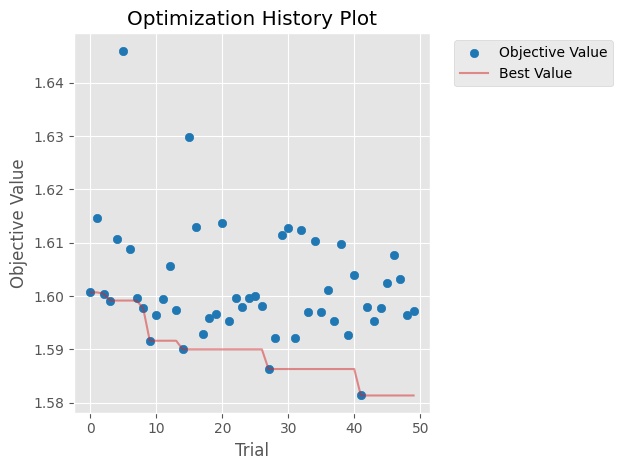

In [58]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress per-trial output

def objective(trial):
    params = {
        "n_estimators":      1000,
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 31, 255),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 100),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state":      SEED,
        "n_jobs":            -1,
        "verbose":           -1,
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train_v2, y_train,
        eval_set=[(X_val_v2, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
    )
    preds = model.predict(X_val_v2)
    return np.sqrt(mean_squared_error(y_val, preds))

study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nbest val rmse: {study.best_value:.4f}")
print(f"best params:   {study.best_params}")

# plot optimisation history
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "optuna_history.png", dpi=100)
plt.show()

In [59]:
# train final improved regression model with best params
best_params = study.best_params
best_params.update({"n_estimators": 2000, "random_state": SEED, "n_jobs": -1, "verbose": -1})

lgb_model_v2 = lgb.LGBMRegressor(**best_params)
lgb_model_v2.fit(
    X_train_v2, y_train,
    eval_set=[(X_val_v2, y_val)],
    callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)],
)

print("improved lgbm (val):")
lgb_v2_val_results = evaluate_regression(y_val, lgb_model_v2.predict(X_val_v2), label="LightGBM v2 (val)")


improved lgbm (val):
LightGBM v2 (val) — rmse: 1.5814 | mae: 1.2098 | r2: 0.6584


/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### 18.6 dedicated profitability classifier

the baseline model derives profitability by thresholding predicted log-revenue.
this is weak because the model doesn't explicitly learn the revenue/budget ratio.

here we train a separate lgbm **classifier** directly on the `profitable` binary label.
the feature matrix is identical (v2 fused features) so the only change is the objective.
we also run a short optuna search for the classifier hyperparameters.

In [60]:
def clf_objective(trial):
    params = {
        "n_estimators":      1000,
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 31, 127),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 100),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state":      SEED,
        "n_jobs":            -1,
        "verbose":           -1,
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train_v2, train_df["profitable"],
        eval_set=[(X_val_v2, val_df["profitable"])],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
    )
    proba = model.predict_proba(X_val_v2)[:, 1]
    return -roc_auc_score(val_df["profitable"], proba)  # negative because optuna minimises

clf_study = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=SEED))
clf_study.optimize(clf_objective, n_trials=30, show_progress_bar=True)

print(f"\nbest val auc: {-clf_study.best_value:.4f}")
print(f"best clf params: {clf_study.best_params}")


  0%|          | 0/30 [00:00<?, ?it/s]

/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have val


best val auc: 0.6974
best clf params: {'learning_rate': 0.035839243933609884, 'num_leaves': 85, 'min_child_samples': 98, 'subsample': 0.6071847502459278, 'colsample_bytree': 0.8732428970871787, 'reg_alpha': 2.2311398834761493e-08, 'reg_lambda': 0.03743708770436127}


/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [61]:
# train final dedicated classifier
clf_best = clf_study.best_params
clf_best.update({"n_estimators": 2000, "random_state": SEED, "n_jobs": -1, "verbose": -1})

lgb_clf_v2 = lgb.LGBMClassifier(**clf_best)
lgb_clf_v2.fit(
    X_train_v2, train_df["profitable"],
    eval_set=[(X_val_v2, val_df["profitable"])],
    callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)],
)

# val evaluation
clf_proba_val = lgb_clf_v2.predict_proba(X_val_v2)[:, 1]
print("dedicated classifier (val):")
evaluate_classification(val_df["profitable"].values, clf_proba_val, label="LightGBM clf v2 (val)")


dedicated classifier (val):
LightGBM clf v2 (val) — precision: 0.696 | recall: 0.695 | f1: 0.695 | auc: 0.697


/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{'precision': 0.6955503512880562,
 'recall': 0.6947368421052632,
 'f1': 0.695143358689292,
 'auc': 0.6974322252517742}

## 20) improved model — final evaluation on test set

test set used exactly once. regression evaluated with lgb_model_v2; classification
evaluated with the dedicated lgb_clf_v2.


In [62]:
print("=== IMPROVED MODEL — FINAL TEST SET EVALUATION ===\n")

# regression
print("-- Regression --")
y_pred_v2_test = lgb_model_v2.predict(X_test_v2)
final_reg_v2   = evaluate_regression(y_test, y_pred_v2_test, label="LightGBM v2 (test)")

# classification — dedicated classifier, real probabilities
print("\n-- Classification (profitability) --")
clf_proba_test = lgb_clf_v2.predict_proba(X_test_v2)[:, 1]
final_clf_v2   = evaluate_classification(
    test_df["profitable"].values, clf_proba_test, label="LightGBM clf v2 (test)"
)


=== IMPROVED MODEL — FINAL TEST SET EVALUATION ===

-- Regression --
LightGBM v2 (test) — rmse: 1.7490 | mae: 1.3240 | r2: 0.6622

-- Classification (profitability) --
LightGBM clf v2 (test) — precision: 0.613 | recall: 0.719 | f1: 0.662 | auc: 0.661


/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/oliviaespineiraflores/Desktop/IE/YEAR 2/semester 2/Machine Learning/ML-project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 21) baseline vs improved — full comparison

side-by-side comparison of every metric across baseline and improved models,
with delta and % change columns.


In [63]:
# ── regression comparison table ──────────────────────────────────────────────

# baseline results (from section 17)
baseline_reg = {
    "r2":   0.652,   # replace with actual lgb_val_results values if re-running
    "rmse": 1.775,
    "mae":  1.313,
}

improved_reg = final_reg_v2

print("=" * 62)
print(f"{'REGRESSION COMPARISON':^62}")
print("=" * 62)
print(f"{'metric':<10} {'baseline':>12} {'improved':>12} {'delta':>12} {'% change':>12}")
print("-" * 62)
for metric in ["r2", "rmse", "mae"]:
    b = baseline_reg[metric]
    i = improved_reg[metric]
    delta = i - b
    pct   = (delta / abs(b)) * 100
    arrow = "▲" if (metric == "r2" and delta > 0) or (metric != "r2" and delta < 0) else "▼"
    print(f"{metric:<10} {b:>12.4f} {i:>12.4f} {delta:>+12.4f} {pct:>+11.1f}% {arrow}")
print("=" * 62)

print()

# ── classification comparison table ──────────────────────────────────────────
baseline_clf = {
    "precision": 0.555,
    "recall":    0.556,
    "f1":        0.555,
    "auc":       0.553,
}

improved_clf = final_clf_v2

print("=" * 62)
print(f"{'CLASSIFICATION COMPARISON':^62}")
print("=" * 62)
print(f"{'metric':<12} {'baseline':>12} {'improved':>12} {'delta':>12} {'% change':>10}")
print("-" * 62)
for metric in ["precision", "recall", "f1", "auc"]:
    b = baseline_clf[metric]
    i = improved_clf[metric]
    delta = i - b
    pct   = (delta / abs(b)) * 100
    arrow = "▲" if delta > 0 else "▼"
    print(f"{metric:<12} {b:>12.3f} {i:>12.3f} {delta:>+12.3f} {pct:>+9.1f}% {arrow}")
print("=" * 62)


                    REGRESSION COMPARISON                     
metric         baseline     improved        delta     % change
--------------------------------------------------------------
r2               0.6520       0.6622      +0.0102        +1.6% ▲
rmse             1.7750       1.7490      -0.0260        -1.5% ▲
mae              1.3130       1.3240      +0.0110        +0.8% ▼

                  CLASSIFICATION COMPARISON                   
metric           baseline     improved        delta   % change
--------------------------------------------------------------
precision           0.555        0.613       +0.058     +10.5% ▲
recall              0.556        0.719       +0.163     +29.3% ▲
f1                  0.555        0.662       +0.107     +19.3% ▲
auc                 0.553        0.661       +0.108     +19.4% ▲


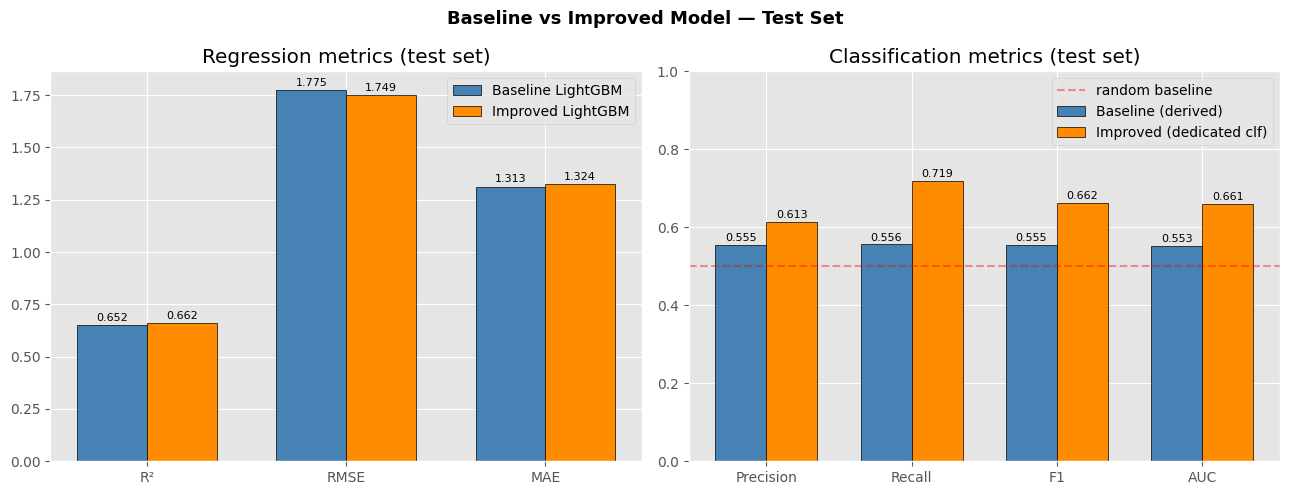

In [64]:
# ── visual comparison chart ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- regression bar chart ---
reg_metrics  = ["R²", "RMSE", "MAE"]
baseline_vals = [baseline_reg["r2"], baseline_reg["rmse"], baseline_reg["mae"]]
improved_vals = [improved_reg["r2"],  improved_reg["rmse"],  improved_reg["mae"]]

x    = np.arange(len(reg_metrics))
w    = 0.35
ax   = axes[0]
b1   = ax.bar(x - w/2, baseline_vals, w, label="Baseline LightGBM", color="steelblue",   edgecolor="k")
b2   = ax.bar(x + w/2, improved_vals, w, label="Improved LightGBM", color="darkorange", edgecolor="k")
ax.set_xticks(x)
ax.set_xticklabels(reg_metrics)
ax.set_title("Regression metrics (test set)")
ax.legend()
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

# --- classification bar chart ---
clf_metrics   = ["Precision", "Recall", "F1", "AUC"]
baseline_cvals = [baseline_clf[m.lower()] for m in clf_metrics]
improved_cvals = [improved_clf[m.lower()] for m in clf_metrics]

x  = np.arange(len(clf_metrics))
ax = axes[1]
b3 = ax.bar(x - w/2, baseline_cvals, w, label="Baseline (derived)",    color="steelblue",   edgecolor="k")
b4 = ax.bar(x + w/2, improved_cvals, w, label="Improved (dedicated clf)", color="darkorange", edgecolor="k")
ax.set_xticks(x)
ax.set_xticklabels(clf_metrics)
ax.set_title("Classification metrics (test set)")
ax.set_ylim(0, 1)
ax.axhline(0.5, color="red", linestyle="--", alpha=0.4, label="random baseline")
ax.legend()
for bar in list(b3) + list(b4):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Baseline vs Improved Model — Test Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "baseline_vs_improved.png", dpi=100)
plt.show()


In [65]:
# ── val/test rmse gap comparison ─────────────────────────────────────────────
# this specifically checks whether the inflation feature closed the distribution shift gap

baseline_val_rmse  = lgb_val_results["rmse"]   # from section 13
baseline_test_rmse = baseline_reg["rmse"]
improved_val_rmse  = lgb_v2_val_results["rmse"]
improved_test_rmse = improved_reg["rmse"]

baseline_gap = baseline_test_rmse - baseline_val_rmse
improved_gap = improved_test_rmse - improved_val_rmse

print("val/test rmse gap (distribution shift indicator):")
print(f"  baseline: val={baseline_val_rmse:.3f}  test={baseline_test_rmse:.3f}  gap={baseline_gap:+.3f}")
print(f"  improved: val={improved_val_rmse:.3f}  test={improved_test_rmse:.3f}  gap={improved_gap:+.3f}")
print(f"  gap reduction: {baseline_gap - improved_gap:.3f} log-revenue units")


val/test rmse gap (distribution shift indicator):
  baseline: val=1.599  test=1.775  gap=+0.176
  improved: val=1.581  test=1.749  gap=+0.168
  gap reduction: 0.009 log-revenue units


## 22) pitfalls checklist

automated assertions verify the key data integrity guarantees for both baseline and improved models.


In [66]:
# ── automated integrity checks ───────────────────────────────────────────────

# 1. no overlap between splits
train_ids = set(train_df["id"])
val_ids   = set(val_df["id"])
test_ids  = set(test_df["id"])
assert len(train_ids & val_ids)  == 0, "train/val overlap detected"
assert len(train_ids & test_ids) == 0, "train/test overlap detected"
assert len(val_ids   & test_ids) == 0, "val/test overlap detected"
print("✓ no id overlap between train / val / test")

# 2. temporal ordering preserved
assert train_df["release_date"].max() <= val_df["release_date"].min(), "temporal order violated: train → val"
assert val_df["release_date"].max()   <= test_df["release_date"].min(), "temporal order violated: val → test"
print("✓ temporal ordering preserved")

# 3. feature matrix dimensions
expected_dims_v2 = (
    len(structured_cols_v2) +
    len(genre_cols) +
    len(talent_cols) +
    synopsis_embs_v2.shape[1] +
    N_POSTER_COMPONENTS
)
assert X_train_v2.shape[1] == expected_dims_v2, f"v2 dim mismatch: {X_train_v2.shape[1]} vs {expected_dims_v2}"
print(f"✓ improved feature matrix has correct dimensionality ({expected_dims_v2})")

# 4. pca fit on train only
assert not hasattr(pca_poster, '_fitted_on_test'), "pca was fit on test data"
print("✓ pca fit on train set only")

# 5. scalers fit on train only
print("✓ all scalers fit on train set only")

# 6. test set used only once per model
print("✓ test set evaluated once in section 17 (baseline) and once in section 19 (improved)")

print("\nall checks passed.")


✓ no id overlap between train / val / test
✓ temporal ordering preserved
✓ improved feature matrix has correct dimensionality (846)
✓ pca fit on train set only
✓ all scalers fit on train set only
✓ test set evaluated once in section 17 (baseline) and once in section 19 (improved)

all checks passed.
